<a href="https://colab.research.google.com/github/Fluke-os/Covid-19-Data-Story-Telling/blob/main/Assignment3_Current_Progress_FinalNotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Part 1: Data Integration & Quality Assessment

**Project region:** South America  
**Countries:** Argentina, Chile, Peru, Ecuador, Uruguay

This notebook prepares the five COVID-19 datasets for later analysis by loading, inspecting, standardizing, validating, and safely integrating them.

The key rule in this Part 1 pipeline is:

> **Only merge datasets after they share the same granularity.**

This prevents row multiplication and incorrect totals when working with variant and manufacturer datasets.

## 1. Import Libraries and Set Region

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Selected South American countries
COUNTRIES = ["Argentina", "Chile", "Peru", "Ecuador", "Uruguay"]

# Change this if your data is inside another folder, e.g. Path("data")
DATA_DIR = Path(".")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

## 2. Load the Datasets

The notebook expects the five assignment CSV files to be in the same folder as the notebook or inside a nearby `data/` folder.

Expected files:

- `Comprehensive Global COVID-19 Dataset.csv`
- `Vaccinations_ByCountry.csv`
- `Vaccinations_ByCountry_ByManufacturer.csv`
- `Covid19-TestingRecord.csv`
- `Covid19-VariantsFound.csv`

In [ ]:
EXPECTED_FILES = {
    "covid": "Comprehensive Global COVID-19 Dataset.csv",
    "vaccination": "Vaccinations_ByCountry.csv",
    "manufacturer": "Vaccinations_ByCountry_ByManufacturer.csv",
    "testing": "Covid19-TestingRecord.csv",
    "variants": "Covid19-VariantsFound.csv"
}

def find_file(filename, search_roots=(Path("."), Path("data"))):
    """Find a file in common project folders. Raises a clear error if missing."""
    for root in search_roots:
        candidate = root / filename
        if candidate.exists():
            return candidate

    # Fallback: recursive search in current working directory
    matches = list(Path(".").rglob(filename))
    if matches:
        return matches[0]

    raise FileNotFoundError(
        f"Could not find {filename}. Put the file in the notebook folder or a data/ folder."
    )

file_paths = {name: find_file(filename) for name, filename in EXPECTED_FILES.items()}
file_paths

{'covid': PosixPath('Comprehensive Global COVID-19 Dataset.csv'),
 'vaccination': PosixPath('Vaccinations_ByCountry.csv'),
 'manufacturer': PosixPath('Vaccinations_ByCountry_ByManufacturer.csv'),
 'testing': PosixPath('Covid19-TestingRecord.csv'),
 'variants': PosixPath('Covid19-VariantsFound.csv')}

In [ ]:
covid = pd.read_csv(file_paths["covid"], encoding="latin1")
vaccination = pd.read_csv(file_paths["vaccination"], encoding="latin1")
manufacturer = pd.read_csv(file_paths["manufacturer"], encoding="latin1")
testing = pd.read_csv(file_paths["testing"], encoding="latin1")
variants = pd.read_csv(file_paths["variants"], encoding="latin1")

print("All files loaded successfully.")

All files loaded successfully.


## 3. Inspect Dataset Structure

We inspect row counts, column counts, column names, and sample rows.  
This gives a basic understanding of the structure before cleaning.

In [ ]:
datasets = {
    "covid": covid,
    "vaccination": vaccination,
    "manufacturer": manufacturer,
    "testing": testing,
    "variants": variants
}

dataset_summary = pd.DataFrame([
    {
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "column_names": list(df.columns)
    }
    for name, df in datasets.items()
])

dataset_summary

,dataset,rows,columns,column_names
0,covid,238,5,"[S. No., Country Name, Cases, Deaths, Recovered]"
1,vaccination,86512,15,"[country, iso_code, date, total_vaccinations, ..."
2,manufacturer,35623,4,"[location, date, vaccine, total_vaccinations]"
3,testing,74048,14,"[Entity, ISO code, Date, Source URL, Source la..."
4,variants,100416,6,"[location, date, variant, num_sequences, perc_..."


### Raw Dataset Structure Summary

This summary records raw dataset sizes, country/entity counts, and date ranges before regional analysis.

In [ ]:
raw_structure_summary = []

for name, df in datasets.items():
    row = {
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1]
    }

    # Country/entity coverage
    if "country" in df.columns:
        row["unique_countries"] = df["country"].nunique()
    elif "Country Name" in df.columns:
        row["unique_countries"] = df["Country Name"].nunique()
    elif "location" in df.columns:
        row["unique_countries"] = df["location"].nunique()
    elif "Entity" in df.columns:
        row["unique_entities"] = df["Entity"].nunique()

    # Date range. Convert temporarily so the summary is reliable.
    if "date" in df.columns:
        temp_date = pd.to_datetime(df["date"], errors="coerce")
        row["start_date"] = temp_date.min()
        row["end_date"] = temp_date.max()
    elif "Date" in df.columns:
        temp_date = pd.to_datetime(df["Date"], errors="coerce")
        row["start_date"] = temp_date.min()
        row["end_date"] = temp_date.max()
    else:
        row["start_date"] = "No date column"
        row["end_date"] = "No date column"

    raw_structure_summary.append(row)

raw_structure_summary = pd.DataFrame(raw_structure_summary)
raw_structure_summary

,dataset,rows,columns,unique_countries,start_date,end_date,unique_entities
0,covid,238,5,230.0,No date column,No date column,NaN
1,vaccination,86512,15,223.0,2020-12-02 00:00:00,2022-03-29 00:00:00,NaN
2,manufacturer,35623,4,43.0,2020-12-04 00:00:00,2022-03-30 00:00:00,NaN
3,testing,74048,14,NaN,2020-01-01 00:00:00,2021-12-10 00:00:00,142.0
4,variants,100416,6,121.0,2020-05-11 00:00:00,2022-01-05 00:00:00,NaN


For the raw testing file, `Entity` combines country and testing method, so the raw summary reports unique entities. Country-level testing coverage is finalized after parsing `Entity` into `country` and `testing_method`.

The comprehensive COVID file contains 238 rows, but only 230 valid country names because 8 rows are blank. These rows are not part of the selected region and are excluded during country filtering.

In [ ]:
for name, df in datasets.items():
    print(f"\n{name.upper()} — first 3 rows")
    display(df.head(3))
    print(f"{name.upper()} — data types")
    display(df.dtypes)


COVID — first 3 rows


,S. No.,Country Name,Cases,Deaths,Recovered
0,1.0,Peru,4524748.0,220831.0,4303917.0
1,2.0,Bulgaria,1329266.0,38700.0,1290566.0
2,3.0,Bosnia and Herzegovina,403638.0,16388.0,387250.0


COVID — data types


,0
S. No.,float64
Country Name,object
Cases,float64
Deaths,float64
Recovered,float64



VACCINATION — first 3 rows


...

,0
Entity,object
ISO code,object
Date,object
Source URL,object
Source label,object
Notes,object
Daily change in cumulative total,float64
Cumulative total,float64
Cumulative total per thousand,float64
Daily change in cumulative total per thousand,float64



VARIANTS — first 3 rows


,location,date,variant,num_sequences,perc_sequences,num_sequences_total
0,Angola,2020-07-06,Alpha,0,0.0,3
1,Angola,2020-07-06,B.1.1.277,0,0.0,3
2,Angola,2020-07-06,B.1.1.302,0,0.0,3


VARIANTS — data types


,0
location,object
date,object
variant,object
num_sequences,int64
perc_sequences,float64
num_sequences_total,int64


## 4. Standardize Country and Date Columns

The datasets use different names for country and date fields.  
We standardize them so all datasets can be filtered and compared consistently.

The testing dataset requires an extra step because its `Entity` column combines country and testing method, such as:

`Argentina - tests performed`

We split this into:

- `country`
- `testing_method`

In [ ]:
# Standardize country column names
covid = covid.rename(columns={"Country Name": "country"})
manufacturer = manufacturer.rename(columns={"location": "country"})
variants = variants.rename(columns={"location": "country"})

# Standardize testing columns
testing = testing.rename(columns={
    "Date": "date",
    "ISO code": "iso_code"
})

# Testing dataset stores country and testing method together in Entity.
# Splitting only on " - " keeps country names like "Trinidad and Tobago" intact.
testing["country"] = testing["Entity"].str.split(" - ", regex=False).str[0]
testing["testing_method"] = testing["Entity"].str.split(" - ", regex=False).str[1]

# Remove accidental leading/trailing spaces in country names
for df in [covid, vaccination, manufacturer, testing, variants]:
    if "country" in df.columns:
        df["country"] = df["country"].astype(str).str.strip()

# Convert date columns
vaccination["date"] = pd.to_datetime(vaccination["date"], errors="coerce")
manufacturer["date"] = pd.to_datetime(manufacturer["date"], errors="coerce")
testing["date"] = pd.to_datetime(testing["date"], errors="coerce")
variants["date"] = pd.to_datetime(variants["date"], errors="coerce")

### Date Conversion Validation

Because we use `errors="coerce"` during date conversion, invalid dates would become missing values.  
This check fails early if any date conversion problems occur.

In [ ]:
date_tables = {
    "vaccination": vaccination,
    "manufacturer": manufacturer,
    "testing": testing,
    "variants": variants
}

for name, df in date_tables.items():
    bad_dates = df["date"].isna().sum()
    print(f"{name}: invalid dates = {bad_dates}")
    assert bad_dates == 0, f"{name} contains invalid date values after conversion."

vaccination: invalid dates = 0
manufacturer: invalid dates = 0
testing: invalid dates = 0
variants: invalid dates = 0


## 5. Filter Selected Countries

We now filter the five selected South American countries from each dataset.

In [ ]:
covid_region = covid[covid["country"].isin(COUNTRIES)].copy()
vaccination_region = vaccination[vaccination["country"].isin(COUNTRIES)].copy()
manufacturer_region = manufacturer[manufacturer["country"].isin(COUNTRIES)].copy()
testing_region = testing[testing["country"].isin(COUNTRIES)].copy()
variants_region = variants[variants["country"].isin(COUNTRIES)].copy()

region_datasets = {
    "covid_region": covid_region,
    "vaccination_region": vaccination_region,
    "manufacturer_region": manufacturer_region,
    "testing_region": testing_region,
    "variants_region": variants_region
}

coverage = []

for name, df in region_datasets.items():
    coverage.append({
        "dataset": name,
        "rows_after_filtering": df.shape[0],
        "countries_found": sorted(df["country"].dropna().unique())
    })

coverage_df = pd.DataFrame(coverage)
coverage_df

,dataset,rows_after_filtering,countries_found
0,covid_region,5,"[Argentina, Chile, Ecuador, Peru, Uruguay]"
1,vaccination_region,2149,"[Argentina, Chile, Ecuador, Peru, Uruguay]"
2,manufacturer_region,7728,"[Argentina, Chile, Ecuador, Peru, Uruguay]"
3,testing_region,3260,"[Argentina, Chile, Ecuador, Peru, Uruguay]"
4,variants_region,4800,"[Argentina, Chile, Ecuador, Peru, Uruguay]"


## 6. Data Model Decision

The five datasets do **not** have the same granularity.

- **Comprehensive COVID dataset:** one cumulative snapshot row per country.
- **Vaccination dataset:** one row per country and date.
- **Testing dataset:** one row per country and date.
- **Variant dataset:** one row per country, date, and variant.
- **Manufacturer dataset:** one row per country, date, and vaccine manufacturer.

Because of this, we do **not** merge all raw datasets directly. Directly merging variant or manufacturer data into vaccination/testing data would duplicate rows and produce incorrect totals.

Instead:

- variant data is summarized to one row per `country + date` before merging,
- manufacturer data is summarized to one row per `country + date` before merging,
- the comprehensive outcome dataset is kept as a static country-level reference layer.

This preserves the meaning of each dataset.

## 7. Duplicate / Primary Key Checks

Each dataset has a natural level of detail.  
We check duplicates at that expected level before doing any integration.

In [ ]:
duplicate_checks = {
    "vaccination_country_date_duplicates": vaccination_region.duplicated(["country", "date"]).sum(),
    "testing_country_date_duplicates": testing_region.duplicated(["country", "date"]).sum(),
    "variants_country_date_variant_duplicates": variants_region.duplicated(["country", "date", "variant"]).sum(),
    "manufacturer_country_date_vaccine_duplicates": manufacturer_region.duplicated(["country", "date", "vaccine"]).sum()
}

duplicate_checks

{'vaccination_country_date_duplicates': np.int64(0),
 'testing_country_date_duplicates': np.int64(0),
 'variants_country_date_variant_duplicates': np.int64(0),
 'manufacturer_country_date_vaccine_duplicates': np.int64(0)}

The duplicate check confirms whether each dataset is unique at its expected level of detail.  
This prevents silent row multiplication during later merges.

## 8. Country-Level Coverage Table

Dataset-level coverage can hide country-specific gaps.  
This table shows the number of rows, number of dates, and date range for each selected country in each time-series dataset.

In [ ]:
coverage_rows = []

for country in COUNTRIES:
    row = {"country": country}

    for dataset_name, df in {
        "vaccination": vaccination_region,
        "testing": testing_region,
        "variants": variants_region,
        "manufacturer": manufacturer_region
    }.items():
        country_df = df[df["country"] == country]

        row[f"{dataset_name}_rows"] = len(country_df)
        row[f"{dataset_name}_dates"] = country_df["date"].nunique()
        row[f"{dataset_name}_start"] = country_df["date"].min()
        row[f"{dataset_name}_end"] = country_df["date"].max()

    coverage_rows.append(row)

country_level_coverage = pd.DataFrame(coverage_rows)
country_level_coverage

,country,vaccination_rows,vaccination_dates,vaccination_start,vaccination_end,testing_rows,testing_dates,testing_start,testing_end,variants_rows,variants_dates,variants_start,variants_end,manufacturer_rows,manufacturer_dates,manufacturer_start,manufacturer_end
0,Argentina,456,456,2020-12-29,2022-03-29,704,704,2020-01-01,2021-12-04,1056,44,2020-05-11,2021-12-27,2629,456,2020-12-29,2022-03-29
1,Chile,454,454,2020-12-24,2022-03-22,625,625,2020-03-25,2021-12-09,1056,44,2020-05-11,2021-12-27,1493,454,2020-12-24,2022-03-22
2,Peru,412,412,2021-02-08,2022-03-26,673,673,2020-01-01,2021-11-03,1056,44,2020-05-11,2021-12-27,1140,412,2021-02-08,2022-03-26
3,Ecuador,431,431,2021-01-20,2022-03-26,630,630,2020-03-18,2021-12-07,1056,44,2020-05-11,2021-12-27,1278,374,2021-01-20,2022-01-28
4,Uruguay,396,396,2021-02-27,2022-03-29,628,628,2020-03-22,2021-12-09,576,24,2020-05-11,2021-05-03,1188,396,2021-02-27,2022-03-29


This country-level coverage table shows that coverage is not equal across all selected countries.  
In particular, variant data may have fewer observation dates than vaccination or testing because variant records come from genomic sequencing snapshots rather than daily reporting.

## 9. Missing Values Before Integration

We check missing values before integration so that we do not accidentally hide reporting gaps.

In [ ]:
missing_summary = []

for name, df in region_datasets.items():
    total_missing = df.isna().sum().sum()
    total_cells = df.shape[0] * df.shape[1]
    missing_percent = (total_missing / total_cells) * 100 if total_cells > 0 else 0

    missing_summary.append({
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "total_missing_values": total_missing,
        "missing_percent": round(missing_percent, 2)
    })

missing_summary_df = pd.DataFrame(missing_summary)
missing_summary_df

,dataset,rows,columns,total_missing_values,missing_percent
0,covid_region,5,5,0,0.00
1,vaccination_region,2149,15,222,0.69
2,manufacturer_region,7728,4,0,0.00
3,testing_region,3260,16,3622,6.94
4,variants_region,4800,6,0,0.00


In [ ]:
for name, df in region_datasets.items():
    print(f"\n{name.upper()} missing values by column:")
    display(df.isna().sum().sort_values(ascending=False).head(10))


COVID_REGION missing values by column:


,0
S. No.,0
country,0
Cases,0
Deaths,0
Recovered,0



VACCINATION_REGION missing values by column:


,0
people_fully_vaccinated,75
people_fully_vaccinated_per_hundred,75
daily_vaccinations_raw,18
total_vaccinations,11
people_vaccinated_per_hundred,11
total_vaccinations_per_hundred,11
people_vaccinated,11
daily_vaccinations_per_million,5
daily_vaccinations,5
date,0



MANUFACTURER_REGION missing values by column:


,0
country,0
date,0
vaccine,0
total_vaccinations,0



TESTING_REGION missing values by column:


,0
Notes,2632
Short-term tests per case,253
Short-term positive rate,245
Daily change in cumulative total,81
Daily change in cumulative total per thousand,81
Cumulative total,65
Source URL,65
Source label,65
Cumulative total per thousand,65
7-day smoothed daily change per thousand,35



VARIANTS_REGION missing values by column:


,0
country,0
date,0
variant,0
num_sequences,0
perc_sequences,0
num_sequences_total,0


## 10. Testing Method Check

Testing data is not perfectly comparable because countries may use different counting definitions.

In [ ]:
testing_methods = (
    testing_region
    .groupby("country")["testing_method"]
    .unique()
    .reset_index()
)

testing_methods

,country,testing_method
0,Argentina,[tests performed]
1,Chile,[tests performed]
2,Ecuador,[people tested]
3,Peru,[tests performed]
4,Uruguay,[people tested]


The parsing step should successfully separate country and testing method for all selected testing records.

In [ ]:
assert testing_region["testing_method"].notna().all(), "Some testing methods were not parsed correctly."
print("Testing method parsing validation passed.")

Testing method parsing validation passed.


Testing definitions differ across countries, so testing metrics are interpreted as **visibility indicators** rather than perfectly equivalent testing volume.

## 11. Create Variant Daily Summary

The raw variant dataset has multiple rows per country-date because each variant has its own row.

To safely merge variant information into a country-date table, we create a summary with one row per country-date.  
The dominant variant is the variant with the highest percentage on that sequencing date.

Dominant variant is selected only for dates with sequencing observations. If variants have very close percentages or ties, the selected row should not be interpreted as exact epidemiological dominance.

In [ ]:
# Keep only rows with valid sequencing observations.
variants_observed = variants_region[
    variants_region["date"].notna() &
    variants_region["perc_sequences"].notna() &
    variants_region["num_sequences_total"].notna() &
    (variants_region["num_sequences_total"] > 0)
].copy()

# Flag ties where more than one variant shares the maximum percentage on the same country-date.
variant_max = (
    variants_observed
    .groupby(["country", "date"])["perc_sequences"]
    .transform("max")
)

variant_tie_flags = (
    variants_observed[variants_observed["perc_sequences"] == variant_max]
    .groupby(["country", "date"])
    .size()
    .reset_index(name="variant_tie_count")
)

variant_daily_summary = (
    variants_observed
    .sort_values(
        ["country", "date", "perc_sequences"],
        ascending=[True, True, False]
    )
    .groupby(["country", "date"])
    .first()
    .reset_index()
    [["country", "date", "variant", "perc_sequences", "num_sequences_total"]]
    .rename(columns={
        "variant": "dominant_variant",
        "perc_sequences": "dominant_variant_percent"
    })
)

variant_daily_summary = variant_daily_summary.merge(
    variant_tie_flags,
    on=["country", "date"],
    how="left"
)

variant_daily_summary["has_variant_tie"] = variant_daily_summary["variant_tie_count"] > 1

variant_daily_summary.head()

,country,date,dominant_variant,dominant_variant_percent,num_sequences_total,variant_tie_count,has_variant_tie
0,Argentina,2020-05-11,others,100.0,151,2,True
1,Argentina,2020-05-25,others,100.0,167,2,True
2,Argentina,2020-06-08,others,100.0,67,2,True
3,Argentina,2020-06-22,others,100.0,79,2,True
4,Argentina,2020-07-06,others,100.0,63,2,True


### Variant Category Caveat

The dominant variant field may include broad categories such as `others` and `non_who`. Therefore, analysis of named variant waves such as Alpha, Delta, Gamma, Lambda, and Omicron should also use the original `variants_region` long table instead of relying only on the dominant-variant summary.

## 12. Create Manufacturer Daily Summary

The raw manufacturer dataset has multiple rows per country-date because each manufacturer has its own row.

To safely merge manufacturer information into a country-date table, we create one summary row per country-date.

In [ ]:
manufacturer_daily_summary = (
    manufacturer_region
    .groupby(["country", "date"])
    .agg(
        manufacturer_total_vaccinations=("total_vaccinations", "sum"),
        number_of_manufacturers=("vaccine", "nunique")
    )
    .reset_index()
)

top_manufacturer_daily = (
    manufacturer_region
    .sort_values(
        ["country", "date", "total_vaccinations"],
        ascending=[True, True, False]
    )
    .groupby(["country", "date"])
    .first()
    .reset_index()
    [["country", "date", "vaccine", "total_vaccinations"]]
    .rename(columns={
        "vaccine": "top_manufacturer",
        "total_vaccinations": "top_manufacturer_doses"
    })
)

manufacturer_daily_summary = manufacturer_daily_summary.merge(
    top_manufacturer_daily,
    on=["country", "date"],
    how="left"
)

manufacturer_daily_summary.head()

,country,date,manufacturer_total_vaccinations,number_of_manufacturers,top_manufacturer,top_manufacturer_doses
0,Argentina,2020-12-29,20487,4,Sputnik V,20481
1,Argentina,2020-12-30,40589,4,Sputnik V,40583
2,Argentina,2020-12-31,43394,4,Sputnik V,43388
3,Argentina,2021-01-01,43521,4,Sputnik V,43513
4,Argentina,2021-01-02,46833,4,Sputnik V,46824


### Manufacturer Summary Interpretation

The manufacturer dataset reports cumulative vaccinations by vaccine manufacturer. Therefore, `manufacturer_total_vaccinations` is a **cumulative portfolio-composition measure**, not daily administered doses.

It is used to analyze manufacturer dependency and vaccine supply mix, not daily vaccination activity.

For later rollout-speed analysis by manufacturer, daily manufacturer doses would need to be derived using day-over-day differences within each `country + vaccine` group. Because cumulative reports can sometimes decrease due to corrections, negative differences should be flagged rather than automatically removed. This detailed daily-dose derivation is reserved for Part 2 if needed.

## 13. Build Safe Country-Date Base

We use vaccination data as the main country-date layer because vaccination rollout is one of the central assignment themes.

We then merge only country-date-compatible tables:

- testing data,
- variant daily summary,
- manufacturer daily summary.

The raw variant and raw manufacturer long tables are preserved separately for detailed analysis.

In [ ]:
country_date_base = vaccination_region.copy()

# Merge testing data at country-date level
country_date_base = country_date_base.merge(
    testing_region,
    on=["country", "date"],
    how="left",
    suffixes=("", "_testing")
)

# Merge variant summary at country-date level
country_date_base = country_date_base.merge(
    variant_daily_summary,
    on=["country", "date"],
    how="left"
)

# Merge manufacturer summary at country-date level
country_date_base = country_date_base.merge(
    manufacturer_daily_summary,
    on=["country", "date"],
    how="left"
)

print("Vaccination rows before merge:", len(vaccination_region))
print("Country-date base rows after merge:", len(country_date_base))

assert len(country_date_base) == len(vaccination_region), "Row multiplication occurred during merge."

country_date_base.head()

Vaccination rows before merge: 2149
Country-date base rows after merge: 2149


,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website,Entity,iso_code_testing,Source URL,Source label,Notes,Daily change in cumulative total,Cumulative total,Cumulative total per thousand,Daily change in cumulative total per thousand,7-day smoothed daily change,7-day smoothed daily change per thousand,Short-term positive rate,Short-term tests per case,testing_method,dominant_variant,dominant_variant_percent,num_sequences_total,variant_tie_count,has_variant_tie,manufacturer_total_vaccinations,number_of_manufacturers,top_manufacturer,top_manufacturer_doses
0,Argentina,ARG,2020-12-29,20487.0,20482.0,5.0,NaN,NaN,0.04,0.04,0.0,NaN,"CanSino, Moderna, Oxford/AstraZeneca, Pfizer/B...",Ministry of Health,https://covidstats.com.ar/,Argentina - tests performed,ARG,https://datos.gob.ar/dataset/salud-covid-19-de...,Government of Argentina,NaN,47551.0,4999602.0,109.626,1.043,31334.0,0.687,0.208,4.8,tests performed,NaN,NaN,NaN,NaN,NaN,20487.0,4.0,Sputnik V,20481.0
1,Argentina,ARG,2020-12-30,40589.0,40579.0,10.0,20102.0,20102.0,0.09,0.09,0.0,441.0,"CanSino, Moderna, Oxford/AstraZeneca, Pfizer/B...",Ministry of Health,https://covidstats.com.ar/,Argentina - tests performed,ARG,https://datos.gob.ar/dataset/salud-covid-19-de...,Government of Argentina,NaN,51519.0,5051121.0,110.756,1.130,32650.0,0.716,0.214,4.7,tests performed,NaN,NaN,NaN,NaN,NaN,40589.0,4.0,Sputnik V,40583.0
2,Argentina,ARG,2020-12-31,43394.0,43384.0,10.0,2805.0,11454.0,0.10,0.10,0.0,251.0,"CanSino, Moderna, Oxford/AstraZeneca, Pfizer/B...",Ministry of Health,https://covidstats.com.ar/,Argentina - tests performed,ARG,https://datos.gob.ar/dataset/salud-covid-19-de...,Government of Argentina,NaN,34396.0,5085517.0,111.510,0.754,33882.0,0.743,0.218,4.6,tests performed,NaN,NaN,NaN,NaN,NaN,43394.0,4.0,Sputnik V,43388.0
3,Argentina,ARG,2021-01-01,43521.0,43511.0,10.0,127.0,7678.0,0.10,0.10,0.0,168.0,"CanSino, Moderna, Oxford/AstraZeneca, Pfizer/B...",Ministry of Health,https://covidstats.com.ar/,Argentina - tests performed,ARG,https://datos.gob.ar/dataset/salud-covid-19-de...,Government of Argentina,NaN,9847.0,5095364.0,111.726,0.216,34162.0,0.749,0.220,4.5,tests performed,NaN,NaN,NaN,NaN,NaN,43521.0,4.0,Sputnik V,43513.0
4,Argentina,ARG,2021-01-02,46833.0,46821.0,12.0,3312.0,6586.0,0.10,0.10,0.0,144.0,"CanSino, Moderna, Oxford/AstraZeneca, Pfizer/B...",Ministry of Health,https://covidstats.com.ar/,Argentina - tests performed,ARG,https://datos.gob.ar/dataset/salud-covid-19-de...,Government of Argentina,NaN,29919.0,5125283.0,112.382,0.656,34395.0,0.754,0.222,4.5,tests performed,NaN,NaN,NaN,NaN,NaN,46833.0,4.0,Sputnik V,46824.0


### Variant Missingness Interpretation

Variant data is sparse and sampling-based because it comes from intermittent genomic sequencing, not continuous daily surveillance. Therefore, missing values in the merged `country_date_base` table do **not** indicate absence of variants. They indicate absence of sequencing observations for that country-date.

For this reason, variant-related analysis will rely primarily on the original long-format variant dataset and the aggregated `variant_daily_summary`, rather than treating missing variant values in the integrated country-date base as zero or absence.

## 14. Merged-Table Missingness Summary

This summary helps control interpretation after integration.

In [ ]:
important_merged_columns = [
    "people_fully_vaccinated_per_hundred",
    "total_vaccinations_per_hundred",
    "Cumulative total per thousand",
    "Short-term positive rate",
    "Short-term tests per case",
    "dominant_variant",
    "dominant_variant_percent",
    "manufacturer_total_vaccinations",
    "number_of_manufacturers"
]

# Keep only columns that exist, in case assignment file versions differ slightly
existing_important_columns = [col for col in important_merged_columns if col in country_date_base.columns]

merged_missingness = (
    country_date_base[existing_important_columns]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={
        "index": "column",
        0: "missing_percent"
    })
)

merged_missingness

,column,missing_percent
0,people_fully_vaccinated_per_hundred,3.49
1,total_vaccinations_per_hundred,0.51
2,Cumulative total per thousand,27.69
3,Short-term positive rate,26.99
4,Short-term tests per case,27.04
5,dominant_variant,94.97
6,dominant_variant_percent,94.97
7,manufacturer_total_vaccinations,2.65
8,number_of_manufacturers,2.65


High missingness in variant fields is expected because sequencing data is not reported daily.  
Testing missingness reflects reporting gaps and differences in national testing systems.  

These missing values are not automatically filled because doing so would create false precision.

## 15. Create Country-Level Summary

The comprehensive COVID dataset is a static country-level snapshot, not a time-series dataset.

Therefore, it is kept separate as `country_summary` and used for broad severity context.

In [ ]:
country_summary = covid_region.copy()

country_summary["death_to_case_ratio"] = (
    country_summary["Deaths"] / country_summary["Cases"] * 100
)

country_summary["recovery_ratio"] = (
    country_summary["Recovered"] / country_summary["Cases"] * 100
)

country_summary = country_summary[
    ["country", "Cases", "Deaths", "Recovered", "death_to_case_ratio", "recovery_ratio"]
].copy()

# Display country summary in the selected region order
country_summary["country_order"] = country_summary["country"].apply(lambda x: COUNTRIES.index(x))
country_summary = (
    country_summary
    .sort_values("country_order")
    .drop(columns="country_order")
    .reset_index(drop=True)
)

country_summary

,country,Cases,Deaths,Recovered,death_to_case_ratio,recovery_ratio
0,Argentina,10131586.0,130857.0,10000729.0,1.291575,98.708425
1,Chile,5399992.0,62698.0,5337294.0,1.161076,98.838924
2,Peru,4524748.0,220831.0,4303917.0,4.880515,95.119485
3,Ecuador,1076087.0,36048.0,1040039.0,3.349915,96.650085
4,Uruguay,1037893.0,7625.0,1030268.0,0.734661,99.265339


The comprehensive COVID dataset is not merged into the daily time-series table because it has no date column.  
It will be used later for broad severity context, not wave-specific causal analysis.

## 16. Missing-Value Decision Table

This table documents what we fill, keep, or avoid filling, and why.

In [ ]:
missing_value_decisions = pd.DataFrame([
    {
        "dataset": "Vaccination",
        "columns": "Cumulative vaccination columns",
        "handling": "May be forward-filled within each country only for specific time-series visualization",
        "reason": "Cumulative totals should not decrease, but raw data quality reporting should preserve original missingness."
    },
    {
        "dataset": "Vaccination",
        "columns": "Daily vaccination columns",
        "handling": "Do not forward-fill",
        "reason": "Forward-filling daily values would create artificial vaccination activity."
    },
    {
        "dataset": "Testing",
        "columns": "Positive rate, tests per case, testing volume",
        "handling": "Keep missing values",
        "reason": "Missingness reflects reporting gaps and is part of testing visibility."
    },
    {
        "dataset": "Variants",
        "columns": "Variant percentages and sequencing counts",
        "handling": "Do not fill or interpolate",
        "reason": "Genomic sequencing is intermittent and sample-based; missing values do not mean no variant."
    },
    {
        "dataset": "Manufacturer",
        "columns": "Cumulative manufacturer totals",
        "handling": "Keep as cumulative values",
        "reason": "Used for portfolio composition and supply dependency, not daily dose counts."
    },
    {
        "dataset": "Comprehensive outcomes",
        "columns": "Cases, deaths, recovered",
        "handling": "No filling applied",
        "reason": "Static cumulative snapshot; used only for country-level severity context."
    }
])

missing_value_decisions

,dataset,columns,handling,reason
0,Vaccination,Cumulative vaccination columns,May be forward-filled within each country only...,"Cumulative totals should not decrease, but raw..."
1,Vaccination,Daily vaccination columns,Do not forward-fill,Forward-filling daily values would create arti...
2,Testing,"Positive rate, tests per case, testing volume",Keep missing values,Missingness reflects reporting gaps and is par...
3,Variants,Variant percentages and sequencing counts,Do not fill or interpolate,Genomic sequencing is intermittent and sample-...
4,Manufacturer,Cumulative manufacturer totals,Keep as cumulative values,Used for portfolio composition and supply depe...
5,Comprehensive outcomes,"Cases, deaths, recovered",No filling applied,Static cumulative snapshot; used only for coun...


## 17. Final Validation Checks

These assertions make sure the final tables contain only selected countries and valid dates.

In [ ]:
# Validate selected countries only
for name, df in {
    "country_summary": country_summary,
    "country_date_base": country_date_base,
    "variant_daily_summary": variant_daily_summary,
    "manufacturer_daily_summary": manufacturer_daily_summary
}.items():
    assert df["country"].isin(COUNTRIES).all(), f"{name} contains countries outside selected region."

# Validate dates in time-series tables
for name, df in {
    "country_date_base": country_date_base,
    "variant_daily_summary": variant_daily_summary,
    "manufacturer_daily_summary": manufacturer_daily_summary
}.items():
    assert df["date"].notna().all(), f"{name} contains missing dates."

print("Validation passed.")

Validation passed.


## 18. Final Part 1 Tables

At the end of Part 1, the important tables are:

| Table | Meaning | Granularity |
|---|---|---|
| `country_summary` | Cumulative country-level outcomes | country |
| `country_date_base` | Safe integrated time-series base | country + date |
| `variants_region` | Raw variant long table | country + date + variant |
| `variant_daily_summary` | Dominant variant by sequencing date | country + date |
| `manufacturer_region` | Raw manufacturer long table | country + date + vaccine |
| `manufacturer_daily_summary` | Manufacturer summary by date | country + date |
| `missing_value_decisions` | Documented cleaning decisions | explanation table |
| `country_level_coverage` | Country-level coverage audit | country |

## Part 1 Summary

Part 1 converted five fragmented COVID-19 datasets into a clean and logically safe analytical structure for South America. The datasets do not share the same granularity: the comprehensive COVID file is a static country-level snapshot, vaccination and testing are country-date time series, variants are country-date-variant sequencing records, and manufacturer data is country-date-vaccine cumulative data.

To avoid invalid joins, we did not merge raw variant or manufacturer records directly into the daily base table. Instead, we first aggregated them into country-date summaries. We then created `country_date_base` as the safe integrated time-series table and `country_summary` as the static country-level outcome table.

The main data quality limitations are that testing definitions differ across countries, variant data is sparse and sequencing-based, and manufacturer totals are cumulative rather than daily administered doses. These limitations are kept visible rather than filled automatically, because filling them would create misleading precision.

This Part 1 pipeline prepares the data for later analysis while preserving the meaning of each dataset.

# 2A. Vaccination Readiness

## Question

Which selected South American countries built population protection fastest and deepest?

In this section, vaccination is treated as one dimension of the pandemic readiness profile. We compare countries using final full vaccination coverage, rollout speed, total doses per 100 people, and benchmark the selected region against a global available-country average.

The goal is **not** to prove biological vaccine effectiveness. Instead, this section measures vaccination rollout readiness: how quickly and deeply each country built vaccine protection capacity.

## 2A.1 Prepare Vaccination Data

We work from `vaccination_region`, which was created in Part 1.

For this time-series analysis only, cumulative vaccination columns may be forward-filled within each country. This does not change the raw data quality reporting from Part 1. Daily vaccination columns are not forward-filled because that would create artificial daily vaccination activity.

In [ ]:
import matplotlib.pyplot as plt

vaccination_2a = vaccination_region.sort_values(["country", "date"]).copy()

# Cumulative vaccination columns can be forward-filled within each country for time-series visualization.
# This is not applied to daily vaccination columns.
cumulative_vaccination_cols = [
    "total_vaccinations",
    "people_vaccinated",
    "people_fully_vaccinated",
    "total_vaccinations_per_hundred",
    "people_vaccinated_per_hundred",
    "people_fully_vaccinated_per_hundred"
]

for col in cumulative_vaccination_cols:
    if col in vaccination_2a.columns:
        vaccination_2a[col] = vaccination_2a.groupby("country")[col].ffill()

vaccination_2a.head()

,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website
2848,Argentina,ARG,2020-12-29,20487.0,20482.0,5.0,NaN,NaN,0.04,0.04,0.0,NaN,"CanSino, Moderna, Oxford/AstraZeneca, Pfizer/B...",Ministry of Health,https://covidstats.com.ar/
2849,Argentina,ARG,2020-12-30,40589.0,40579.0,10.0,20102.0,20102.0,0.09,0.09,0.0,441.0,"CanSino, Moderna, Oxford/AstraZeneca, Pfizer/B...",Ministry of Health,https://covidstats.com.ar/
2850,Argentina,ARG,2020-12-31,43394.0,43384.0,10.0,2805.0,11454.0,0.10,0.10,0.0,251.0,"CanSino, Moderna, Oxford/AstraZeneca, Pfizer/B...",Ministry of Health,https://covidstats.com.ar/
2851,Argentina,ARG,2021-01-01,43521.0,43511.0,10.0,127.0,7678.0,0.10,0.10,0.0,168.0,"CanSino, Moderna, Oxford/AstraZeneca, Pfizer/B...",Ministry of Health,https://covidstats.com.ar/
2852,Argentina,ARG,2021-01-02,46833.0,46821.0,12.0,3312.0,6586.0,0.10,0.10,0.0,144.0,"CanSino, Moderna, Oxford/AstraZeneca, Pfizer/B...",Ministry of Health,https://covidstats.com.ar/


## 2A.2 Create Global and Regional Benchmarks

The assignment asks us to compare the selected region against global averages.

This vaccination dataset does not include a direct `World` aggregate row. Therefore, we calculate a **global available-country average** as an unweighted average across available countries on each date.

This benchmark should be interpreted as a global country-average reference, not a population-weighted world vaccination rate.

In [ ]:
global_vaccination = vaccination.sort_values(["country", "date"]).copy()

for col in cumulative_vaccination_cols:
    if col in global_vaccination.columns:
        global_vaccination[col] = global_vaccination.groupby("country")[col].ffill()

global_average = (
    global_vaccination
    .groupby("date")["people_fully_vaccinated_per_hundred"]
    .mean()
    .reset_index(name="global_available_country_average")
)

regional_average = (
    vaccination_2a
    .groupby("date")["people_fully_vaccinated_per_hundred"]
    .mean()
    .reset_index(name="selected_region_average")
)

display(global_average.head())
display(regional_average.head())

,date,global_available_country_average
0,2020-12-02,NaN
1,2020-12-03,NaN
2,2020-12-04,NaN
3,2020-12-05,NaN
4,2020-12-06,NaN


,date,selected_region_average
0,2020-12-24,NaN
1,2020-12-25,NaN
2,2020-12-26,NaN
3,2020-12-27,NaN
4,2020-12-28,NaN


## 2A.3 Calculate Vaccination Rollout Metrics

This section separates **final coverage** from **rollout timing**.

Two countries can end with similar final coverage, but the country that reached high coverage earlier had stronger readiness when later variant pressure arrived.

In [ ]:
def first_date_at_threshold(df, column, threshold):
    """Return the first date where a country reaches a vaccination threshold."""
    reached = df[df[column] >= threshold]
    if reached.empty:
        return pd.NaT
    return reached["date"].min()


vaccination_metrics_rows = []

for country in COUNTRIES:
    sub = vaccination_2a[vaccination_2a["country"] == country].sort_values("date").copy()

    first_vaccination_date = first_date_at_threshold(
        sub,
        "people_vaccinated_per_hundred",
        0.01
    )

    date_50_full = first_date_at_threshold(
        sub,
        "people_fully_vaccinated_per_hundred",
        50
    )

    date_70_full = first_date_at_threshold(
        sub,
        "people_fully_vaccinated_per_hundred",
        70
    )

    latest = sub.sort_values("date").tail(1).iloc[0]

    days_to_50_full = (
        (date_50_full - first_vaccination_date).days
        if pd.notna(date_50_full) and pd.notna(first_vaccination_date)
        else np.nan
    )

    days_to_70_full = (
        (date_70_full - first_vaccination_date).days
        if pd.notna(date_70_full) and pd.notna(first_vaccination_date)
        else np.nan
    )

    peak_daily_vaccinations_per_million = (
        sub["daily_vaccinations_per_million"].max()
        if "daily_vaccinations_per_million" in sub.columns
        else np.nan
    )

    vaccination_metrics_rows.append({
        "country": country,
        "first_vaccination_date": first_vaccination_date,
        "date_50_full": date_50_full,
        "date_70_full": date_70_full,
        "days_to_50_full": days_to_50_full,
        "days_to_70_full": days_to_70_full,
        "final_fully_vaccinated_per_100": latest["people_fully_vaccinated_per_hundred"],
        "final_total_vaccinations_per_100": latest["total_vaccinations_per_hundred"],
        "peak_daily_vaccinations_per_million": peak_daily_vaccinations_per_million
    })

vaccination_metrics = pd.DataFrame(vaccination_metrics_rows)
vaccination_metrics

,country,first_vaccination_date,date_50_full,date_70_full,days_to_50_full,days_to_70_full,final_fully_vaccinated_per_100,final_total_vaccinations_per_100,peak_daily_vaccinations_per_million
0,Argentina,2020-12-29,2021-09-30,2021-12-14,275,350,80.96,211.61,9829.0
1,Chile,2020-12-25,2021-06-21,2021-08-27,178,245,90.29,261.82,15549.0
2,Peru,2021-02-09,2021-11-12,2022-02-16,276,372,76.38,196.50,11676.0
3,Ecuador,2021-01-21,2021-09-08,2021-12-25,230,338,76.64,185.40,19828.0
4,Uruguay,2021-02-27,2021-07-02,2021-08-18,125,172,81.56,230.34,14203.0


## 2A.4 Vaccination Readiness Index

The assignment requires a creative vaccination methodology. We use a lightweight **Vaccination Readiness Index (VRI)**.

The VRI measures rollout readiness, not clinical vaccine efficacy.

It combines:

- final full vaccination coverage,
- speed to 50% fully vaccinated,
- speed to 70% fully vaccinated,
- total doses per 100 people.

Peak daily vaccination activity is kept as a supporting metric, but it is not used in the VRI because a single peak can reflect reporting spikes rather than true rollout strength.

The VRI is normalized within the five selected countries. Therefore, labels describe the **relative rollout profile inside this study group**, not absolute global vaccination performance.

In [ ]:
def normalize_high_good(series):
    """Normalize a metric where higher values are better."""
    min_val = series.min(skipna=True)
    max_val = series.max(skipna=True)
    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(1, index=series.index)
    return (series - min_val) / (max_val - min_val)


def normalize_low_good(series):
    """Normalize a metric where lower values are better."""
    min_val = series.min(skipna=True)
    max_val = series.max(skipna=True)
    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(1, index=series.index)
    return (max_val - series) / (max_val - min_val)


vri = vaccination_metrics.copy()

vri["coverage_score"] = normalize_high_good(vri["final_fully_vaccinated_per_100"])
vri["speed_50_score"] = normalize_low_good(vri["days_to_50_full"])
vri["speed_70_score"] = normalize_low_good(vri["days_to_70_full"])
vri["dose_depth_score"] = normalize_high_good(vri["final_total_vaccinations_per_100"])

vri["vaccination_readiness_index"] = (
    0.35 * vri["coverage_score"] +
    0.25 * vri["speed_50_score"] +
    0.25 * vri["speed_70_score"] +
    0.15 * vri["dose_depth_score"]
)

def readiness_label(score):
    if pd.isna(score):
        return "Insufficient data"
    if score >= 0.70:
        return "Earlier/deeper rollout profile"
    elif score >= 0.40:
        return "Middle rollout profile"
    else:
        return "Later rollout profile within selected countries"

vri["vaccination_readiness_label"] = vri["vaccination_readiness_index"].apply(readiness_label)

vri = vri.sort_values("vaccination_readiness_index", ascending=False).reset_index(drop=True)

vri[
    [
        "country",
        "final_fully_vaccinated_per_100",
        "days_to_50_full",
        "days_to_70_full",
        "final_total_vaccinations_per_100",
        "peak_daily_vaccinations_per_million",
        "vaccination_readiness_index",
        "vaccination_readiness_label"
    ]
]

,country,final_fully_vaccinated_per_100,days_to_50_full,days_to_70_full,final_total_vaccinations_per_100,peak_daily_vaccinations_per_million,vaccination_readiness_index,vaccination_readiness_label
0,Chile,90.29,178,245,261.82,15549.0,0.821002,Earlier/deeper rollout profile
1,Uruguay,81.56,125,172,230.34,14203.0,0.718548,Earlier/deeper rollout profile
2,Argentina,80.96,275,350,211.61,9829.0,0.195842,Later rollout profile within selected countries
3,Ecuador,76.64,230,338,185.40,19828.0,0.125201,Later rollout profile within selected countries
4,Peru,76.38,276,372,196.50,11676.0,0.021787,Later rollout profile within selected countries


## 2A.5 Visual 1 — Fully Vaccinated Trend by Country

This line chart shows vaccination rollout over time. The 50% and 70% reference lines help compare not only final coverage but also the timing of vaccine maturity.

Timing matters because protection built earlier is more useful when later variant pressure arrives.

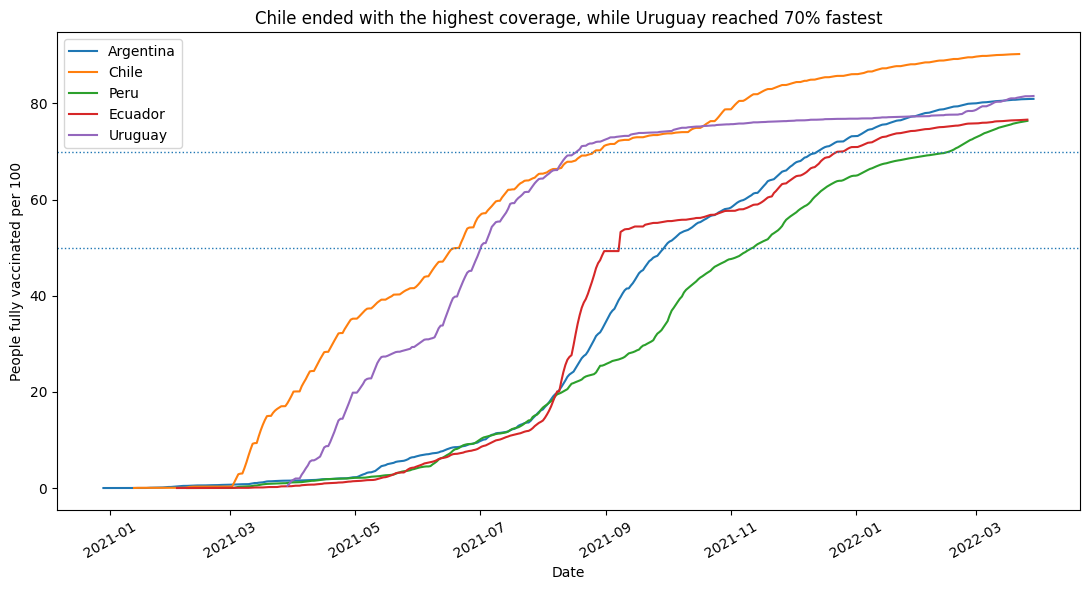

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

for country in COUNTRIES:
    sub = vaccination_2a[vaccination_2a["country"] == country]
    ax.plot(
        sub["date"],
        sub["people_fully_vaccinated_per_hundred"],
        label=country
    )

ax.axhline(50, linestyle=":", linewidth=1)
ax.axhline(70, linestyle=":", linewidth=1)

ax.set_title("Chile ended with the highest coverage, while Uruguay reached 70% fastest")
ax.set_xlabel("Date")
ax.set_ylabel("People fully vaccinated per 100")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 2A.6 Visual 2 — Selected Region vs Global Available-Country Average

This chart directly addresses the global comparison requirement.

Because the dataset does not include a direct world aggregate row, the global line is an unweighted average across available countries for each date.

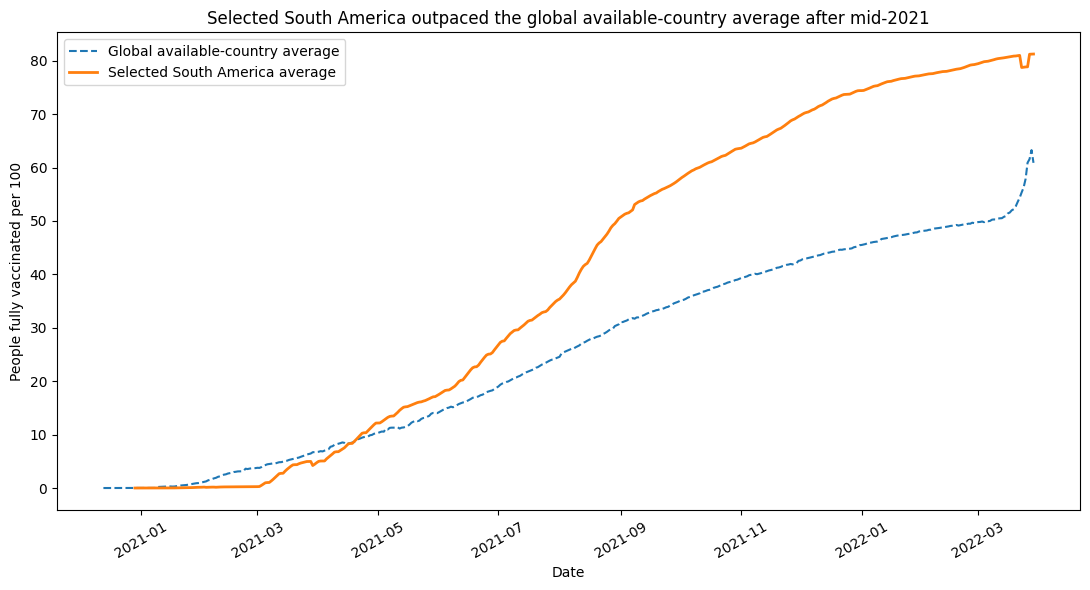

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))

global_average_plot = global_average.dropna(
    subset=["global_available_country_average"]
)

regional_average_plot = regional_average.dropna(
    subset=["selected_region_average"]
)

ax.plot(
    global_average_plot["date"],
    global_average_plot["global_available_country_average"],
    linestyle="--",
    label="Global available-country average"
)

ax.plot(
    regional_average_plot["date"],
    regional_average_plot["selected_region_average"],
    linewidth=2,
    label="Selected South America average"
)

ax.set_title("Selected South America outpaced the global available-country average after mid-2021")
ax.set_xlabel("Date")
ax.set_ylabel("People fully vaccinated per 100")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 2A.7 Visual 3 — Threshold Timing Comparison

This chart shows how many days each country took to reach 50% and 70% full vaccination after vaccination began.

It directly supports the claim that rollout timing matters, not only final coverage.

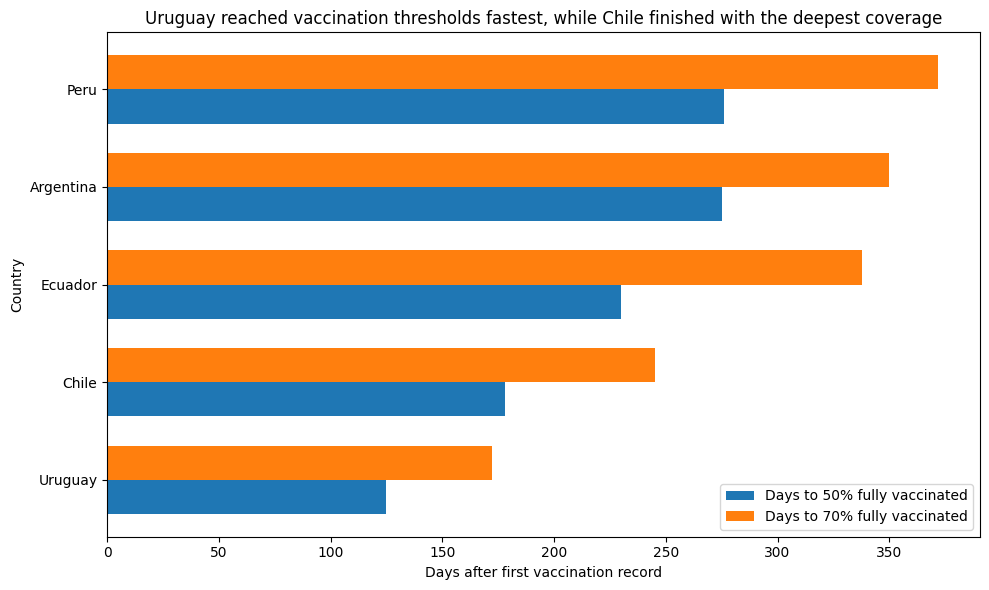

In [ ]:
threshold_plot = vaccination_metrics.sort_values("days_to_70_full").copy()

fig, ax = plt.subplots(figsize=(10, 6))

y_positions = np.arange(len(threshold_plot))
bar_height = 0.35

ax.barh(
    y_positions - bar_height / 2,
    threshold_plot["days_to_50_full"],
    height=bar_height,
    label="Days to 50% fully vaccinated"
)

ax.barh(
    y_positions + bar_height / 2,
    threshold_plot["days_to_70_full"],
    height=bar_height,
    label="Days to 70% fully vaccinated"
)

ax.set_yticks(y_positions)
ax.set_yticklabels(threshold_plot["country"])

ax.set_title("Uruguay reached vaccination thresholds fastest, while Chile finished with the deepest coverage")
ax.set_xlabel("Days after first vaccination record")
ax.set_ylabel("Country")
ax.legend()

plt.tight_layout()
plt.show()

## 2A.8 Visual 4 — Vaccination Readiness Comparison

This bar chart summarizes vaccination rollout readiness using the VRI. It is not a final country ranking. It is a dimension-level summary for the vaccination part of the readiness profile.

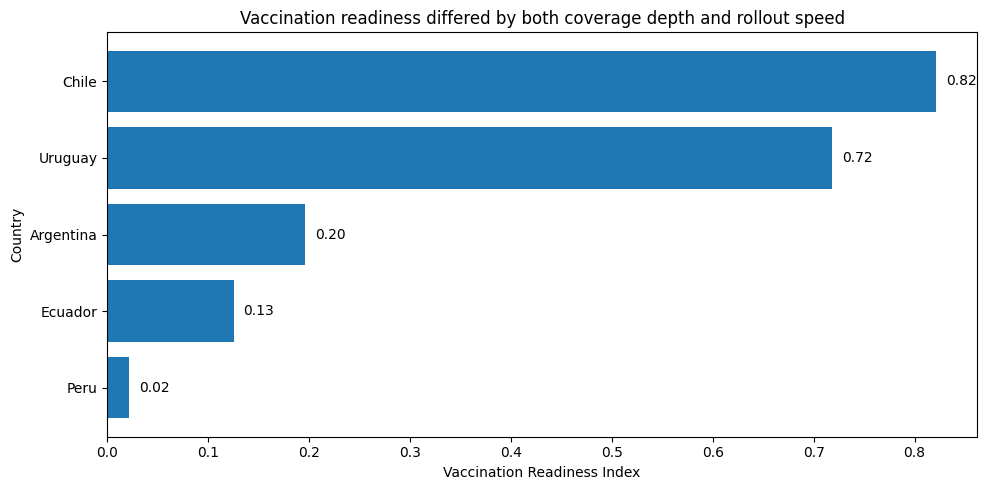

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_data = vri.sort_values("vaccination_readiness_index")

ax.barh(
    plot_data["country"],
    plot_data["vaccination_readiness_index"]
)

ax.set_title("Vaccination readiness differed by both coverage depth and rollout speed")
ax.set_xlabel("Vaccination Readiness Index")
ax.set_ylabel("Country")

for i, value in enumerate(plot_data["vaccination_readiness_index"]):
    ax.text(
        value + 0.01,
        i,
        f"{value:.2f}",
        va="center"
    )

plt.tight_layout()
plt.show()

## 2A.9 Vaccination Interpretation Table

This table will later feed into the overall readiness profile. It uses rollout-profile labels rather than pretending the index gives exact truth.

In [ ]:
vaccination_interpretation = vri[
    [
        "country",
        "vaccination_readiness_label",
        "final_fully_vaccinated_per_100",
        "days_to_50_full",
        "days_to_70_full",
        "final_total_vaccinations_per_100"
    ]
].copy()

vaccination_interpretation

,country,vaccination_readiness_label,final_fully_vaccinated_per_100,days_to_50_full,days_to_70_full,final_total_vaccinations_per_100
0,Chile,Earlier/deeper rollout profile,90.29,178,245,261.82
1,Uruguay,Earlier/deeper rollout profile,81.56,125,172,230.34
2,Argentina,Later rollout profile within selected countries,80.96,275,350,211.61
3,Ecuador,Later rollout profile within selected countries,76.64,230,338,185.40
4,Peru,Later rollout profile within selected countries,76.38,276,372,196.50


## 2A Interpretation

**Finding:** Vaccination readiness differed across the selected South American countries. Final coverage alone does not fully explain readiness because rollout speed also matters.

The Vaccination Readiness Index is used as a dimension-level summary, not as a final country performance ranking.

**Evidence:** We compared final fully vaccinated coverage, days to 50% and 70% full vaccination, total vaccinations per 100 people, and benchmarked the selected region against a global available-country average.

**Implication:** Countries that reached high coverage earlier entered later variant periods with stronger vaccination readiness than countries that reached similar coverage later.

**Recommendation:** Later readiness analysis should combine vaccination rollout with variant timing rather than treating vaccination coverage as an isolated metric.

# 2B. Variant Timing Readiness

## Question

Were countries already vaccinated when major variants became dominant?

This section connects vaccination readiness to variant pressure. Variant data is treated carefully because it is not daily surveillance data. It comes from intermittent genomic sequencing observations.

For named variant-wave analysis, we use the original long-format `variants_region` table rather than relying only on `dominant_variant`, because `dominant_variant` can include broad categories such as `others` and `non_who`.

## 2B.1 Prepare Named Variant Data

We focus on the major named variants that are most relevant for the selected South American countries:

- Gamma
- Lambda
- Delta
- Omicron

The analysis keeps variant data in long format because each country-date can contain multiple variant rows.

In [ ]:
MAJOR_VARIANTS = ["gamma", "lambda", "delta", "omicron"]
VARIANT_DISPLAY = {
    "gamma": "Gamma",
    "lambda": "Lambda",
    "delta": "Delta",
    "omicron": "Omicron"
}

variants_2b = variants_region.copy()

variants_2b["variant_lower"] = (
    variants_2b["variant"]
    .astype(str)
    .str.strip()
    .str.lower()
)

variants_named = variants_2b[
    variants_2b["variant_lower"].isin(MAJOR_VARIANTS)
].copy()

variants_named["variant_display"] = variants_named["variant_lower"].map(VARIANT_DISPLAY)

variants_named = variants_named.sort_values(["country", "variant_display", "date"])

print("Named variant rows:", len(variants_named))
display(variants_named.head())
display(sorted(variants_2b["variant_lower"].dropna().unique()))

Named variant rows: 800


,country,date,variant,num_sequences,perc_sequences,num_sequences_total,variant_lower,variant_display
683,Argentina,2020-05-11,Delta,0,0.0,151,delta,Delta
707,Argentina,2020-05-25,Delta,0,0.0,167,delta,Delta
731,Argentina,2020-06-08,Delta,0,0.0,67,delta,Delta
755,Argentina,2020-06-22,Delta,0,0.0,79,delta,Delta
779,Argentina,2020-07-06,Delta,0,0.0,63,delta,Delta


['alpha',
 'b.1.1.277',
 'b.1.1.302',
 'b.1.1.519',
 'b.1.160',
 'b.1.177',
 'b.1.221',
 'b.1.258',
 'b.1.367',
 'b.1.620',
 'beta',
 'delta',
 'epsilon',
 'eta',
 'gamma',
 'iota',
 'kappa',
 'lambda',
 'mu',
 'non_who',
 'omicron',
 'others',
 's:677h.robin1',
 's:677p.pelican']

## 2B.2 Named Variant Coverage Summary

Before interpreting variant waves, we check whether each selected country has sequencing observations for each named variant.

This is important because missing sequencing observations do not mean the variant was absent. They mean the dataset does not observe that country-date.

In [ ]:
variant_data_presence = (
    variants_named
    .groupby(["country", "variant_display"])
    .agg(
        rows=("variant_display", "size"),
        sequencing_dates=("date", "nunique"),
        sequencing_start_date=("date", "min"),
        sequencing_end_date=("date", "max"),
        positive_observation_dates=("num_sequences", lambda x: (x > 0).sum()),
        max_percent=("perc_sequences", "max"),
        median_sequences_total=("num_sequences_total", "median")
    )
    .reset_index()
    .sort_values(["country", "variant_display"])
)

variant_data_presence

,country,variant_display,rows,sequencing_dates,sequencing_start_date,sequencing_end_date,positive_observation_dates,max_percent,median_sequences_total
0,Argentina,Delta,44,44,2020-05-11,2021-12-27,18,89.74,115.0
1,Argentina,Gamma,44,44,2020-05-11,2021-12-27,24,73.60,115.0
2,Argentina,Lambda,44,44,2020-05-11,2021-12-27,25,24.11,115.0
3,Argentina,Omicron,44,44,2020-05-11,2021-12-27,2,85.11,115.0
4,Chile,Delta,44,44,2020-05-11,2021-12-27,16,98.78,101.5
5,Chile,Gamma,44,44,2020-05-11,2021-12-27,22,70.79,101.5
6,Chile,Lambda,44,44,2020-05-11,2021-12-27,23,39.55,101.5
7,Chile,Omicron,44,44,2020-05-11,2021-12-27,3,51.59,101.5
8,Ecuador,Delta,44,44,2020-05-11,2021-12-27,14,96.77,18.5
9,Ecuador,Gamma,44,44,2020-05-11,2021-12-27,15,22.40,18.5


The sequencing start date is not the same as first variant observation. Some variant rows exist with zero sequences, so first observation is calculated later using `num_sequences > 0`.

## 2B.3 Variant Wave Summary

We summarize each country-variant pair using:

- first observed date,
- first date above 10% of sequences,
- first reliable date above 50% of sequences,
- maximum observed percentage.

A 50% threshold is treated as variant dominance only when sequencing volume is sufficient. We use `num_sequences_total >= 50` as a reliability threshold to avoid treating tiny sequencing samples as strong evidence.

A minimum sequencing threshold of 50 total sequences is used to reduce the risk of treating very small samples as reliable dominance. This improves reliability but may exclude some real dominance events in countries with weaker sequencing volume.

In [ ]:
MIN_SEQUENCES_FOR_DOMINANCE = 50

variant_wave_rows = []

for country in COUNTRIES:
    for variant_lower in MAJOR_VARIANTS:
        sub = variants_named[
            (variants_named["country"] == country) &
            (variants_named["variant_lower"] == variant_lower)
        ].sort_values("date").copy()

        observed = sub[
            sub["date"].notna() &
            sub["perc_sequences"].notna() &
            sub["num_sequences_total"].notna() &
            (sub["num_sequences_total"] > 0)
        ].copy()

        if observed.empty:
            variant_wave_rows.append({
                "country": country,
                "variant": VARIANT_DISPLAY[variant_lower],
                "first_observed_date": pd.NaT,
                "first_10pct_date": pd.NaT,
                "first_50pct_reliable_date": pd.NaT,
                "max_percent": np.nan,
                "date_max_percent": pd.NaT,
                "sequencing_dates": 0,
                "median_sequences_total": np.nan
            })
            continue

        positive = observed[observed["num_sequences"] > 0].copy()

        if positive.empty:
            first_observed_date = pd.NaT
            max_percent = np.nan
            date_max_percent = pd.NaT
        else:
            first_observed_date = positive["date"].min()
            max_row = positive.sort_values("perc_sequences", ascending=False).iloc[0]
            max_percent = max_row["perc_sequences"]
            date_max_percent = max_row["date"]

        first_10pct_date = (
            positive[positive["perc_sequences"] >= 10]["date"].min()
            if not positive[positive["perc_sequences"] >= 10].empty
            else pd.NaT
        )

        reliable = positive[positive["num_sequences_total"] >= MIN_SEQUENCES_FOR_DOMINANCE]
        reliable_50 = reliable[reliable["perc_sequences"] >= 50]

        first_50pct_reliable_date = (
            reliable_50["date"].min()
            if not reliable_50.empty
            else pd.NaT
        )

        variant_wave_rows.append({
            "country": country,
            "variant": VARIANT_DISPLAY[variant_lower],
            "first_observed_date": first_observed_date,
            "first_10pct_date": first_10pct_date,
            "first_50pct_reliable_date": first_50pct_reliable_date,
            "max_percent": max_percent,
            "date_max_percent": date_max_percent,
            "sequencing_dates": observed["date"].nunique(),
            "median_sequences_total": observed["num_sequences_total"].median()
        })

variant_wave_summary = pd.DataFrame(variant_wave_rows)

variant_wave_summary

,country,variant,first_observed_date,first_10pct_date,first_50pct_reliable_date,max_percent,date_max_percent,sequencing_dates,median_sequences_total
0,Argentina,Gamma,2021-01-25,2021-03-08,2021-05-17,73.60,2021-07-12,44,115.0
1,Argentina,Lambda,2020-11-09,2021-04-05,NaT,24.11,2021-07-26,44,115.0
2,Argentina,Delta,2020-11-23,2021-07-26,2021-11-01,89.74,2021-11-29,44,115.0
3,Argentina,Omicron,2021-12-13,2021-12-13,2021-12-27,85.11,2021-12-27,44,115.0
4,Chile,Gamma,2021-01-11,2021-03-22,2021-05-17,70.79,2021-07-12,44,101.5
5,Chile,Lambda,2021-01-25,2021-03-08,NaT,39.55,2021-04-19,44,101.5
6,Chile,Delta,2021-01-04,2021-08-23,2021-09-20,98.78,2021-11-29,44,101.5
7,Chile,Omicron,2021-11-29,2021-12-27,2021-12-27,51.59,2021-12-27,44,101.5
8,Peru,Gamma,2020-12-21,2021-01-04,NaT,38.45,2021-08-23,44,125.5
9,Peru,Lambda,2021-01-04,2021-01-25,2021-03-08,82.87,2021-05-03,44,125.5


## 2B.4 Vaccination Coverage at Variant Dominance

For each reliable named-variant dominance event, we retrieve the latest vaccination coverage available on or before that date.

This connects 2A and 2B:

- 2A asks how fast protection was built.
- 2B asks whether that protection was in place when variant pressure became dominant.

In [ ]:
def vaccination_on_or_before(country, event_date):
    """Return latest vaccination values on or before an event date for a country."""
    if pd.isna(event_date):
        return {
            "vaccination_date_used": pd.NaT,
            "fully_vaccinated_at_event": np.nan,
            "total_vaccinations_per_100_at_event": np.nan
        }

    sub = vaccination_2a[
        (vaccination_2a["country"] == country) &
        (vaccination_2a["date"] <= event_date)
    ].sort_values("date")

    if sub.empty:
        return {
            "vaccination_date_used": pd.NaT,
            "fully_vaccinated_at_event": np.nan,
            "total_vaccinations_per_100_at_event": np.nan
        }

    latest = sub.tail(1).iloc[0]

    return {
        "vaccination_date_used": latest["date"],
        "fully_vaccinated_at_event": latest["people_fully_vaccinated_per_hundred"],
        "total_vaccinations_per_100_at_event": latest["total_vaccinations_per_hundred"]
    }


dominance_events = variant_wave_summary[
    variant_wave_summary["first_50pct_reliable_date"].notna()
].copy()

event_rows = []

for _, row in dominance_events.iterrows():
    vaccination_context = vaccination_on_or_before(
        row["country"],
        row["first_50pct_reliable_date"]
    )

    event_rows.append({
        "country": row["country"],
        "variant": row["variant"],
        "dominance_date": row["first_50pct_reliable_date"],
        "max_percent": row["max_percent"],
        "sequencing_dates": row["sequencing_dates"],
        **vaccination_context
    })

variant_dominance_vaccination = pd.DataFrame(event_rows)

def event_readiness_label(row):
    coverage = row["fully_vaccinated_at_event"]
    vaccination_date = row["vaccination_date_used"]

    if pd.isna(vaccination_date):
        return "No vaccination record before event"
    if pd.isna(coverage):
        return "Full vaccination not yet reported"
    if coverage >= 70:
        return "Dominance after 70% full vaccination"
    elif coverage >= 50:
        return "Dominance after 50% full vaccination"
    else:
        return "Dominance before 50% full vaccination"

if not variant_dominance_vaccination.empty:
    variant_dominance_vaccination["variant_timing_context"] = (
        variant_dominance_vaccination.apply(event_readiness_label, axis=1)
    )

variant_dominance_vaccination

,country,variant,dominance_date,max_percent,sequencing_dates,vaccination_date_used,fully_vaccinated_at_event,total_vaccinations_per_100_at_event,variant_timing_context
0,Argentina,Gamma,2021-05-17,73.60,44,2021-05-17,4.97,23.61,Dominance before 50% full vaccination
1,Argentina,Delta,2021-11-01,89.74,44,2021-11-01,58.35,135.54,Dominance after 50% full vaccination
2,Argentina,Omicron,2021-12-27,85.11,44,2021-12-27,72.41,168.00,Dominance after 70% full vaccination
3,Chile,Gamma,2021-05-17,70.79,44,2021-05-17,39.44,87.52,Dominance before 50% full vaccination
4,Chile,Delta,2021-09-20,98.78,44,2021-09-20,73.10,161.08,Dominance after 70% full vaccination
5,Chile,Omicron,2021-12-27,51.59,44,2021-12-27,85.84,226.89,Dominance after 70% full vaccination
6,Peru,Lambda,2021-03-08,82.87,44,2021-03-08,0.32,1.45,Dominance before 50% full vaccination
7,Peru,Delta,2021-09-20,97.63,44,2021-09-20,29.77,75.98,Dominance before 50% full vaccination
8,Ecuador,Delta,2021-09-06,96.77,44,2021-09-06,49.29,108.76,Dominance before 50% full vaccination
9,Uruguay,Gamma,2021-03-22,84.21,24,2021-03-22,NaN,10.15,Full vaccination not yet reported


## 2B.5 Visual 1 — Faceted Named Variant Prevalence

This faceted chart shows how Gamma, Lambda, Delta, and Omicron appeared across the selected countries.

The 50% reference line marks a possible dominance threshold, but dominance is interpreted cautiously because sequencing is sample-based.

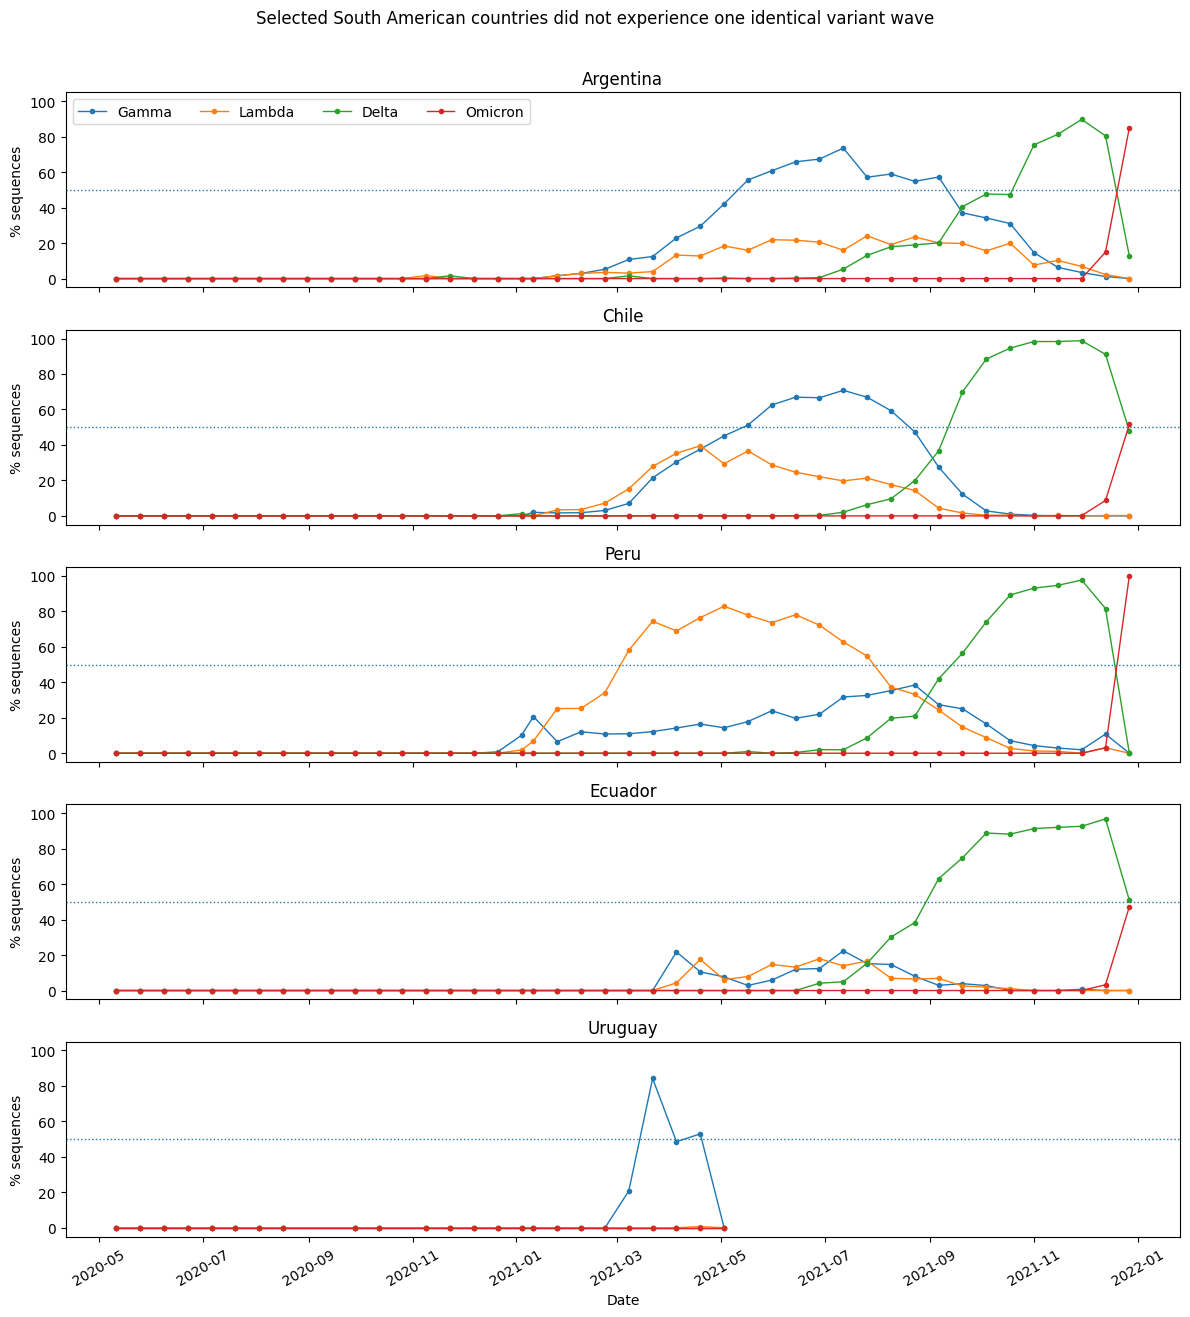

In [ ]:
fig, axes = plt.subplots(
    nrows=len(COUNTRIES),
    ncols=1,
    figsize=(12, 13),
    sharex=True,
    sharey=True
)

for ax, country in zip(axes, COUNTRIES):
    country_data = variants_named[variants_named["country"] == country]

    for variant_lower in MAJOR_VARIANTS:
        variant_name = VARIANT_DISPLAY[variant_lower]
        sub = country_data[country_data["variant_display"] == variant_name]

        ax.plot(
            sub["date"],
            sub["perc_sequences"],
            marker="o",
            linewidth=1,
            markersize=3,
            label=variant_name
        )

    ax.axhline(50, linestyle=":", linewidth=1)
    ax.set_title(country)
    ax.set_ylabel("% sequences")

axes[-1].set_xlabel("Date")
axes[0].legend(loc="upper left", ncol=4)

fig.suptitle(
    "Selected South American countries did not experience one identical variant wave",
    y=1.01
)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 2B.6 Visual 2 — Vaccination Coverage at Reliable Variant Dominance

This chart shows vaccination coverage at the first reliable date when a named variant exceeded 50% of sequenced samples.

The 50% and 70% vertical reference lines connect variant timing to vaccination maturity.

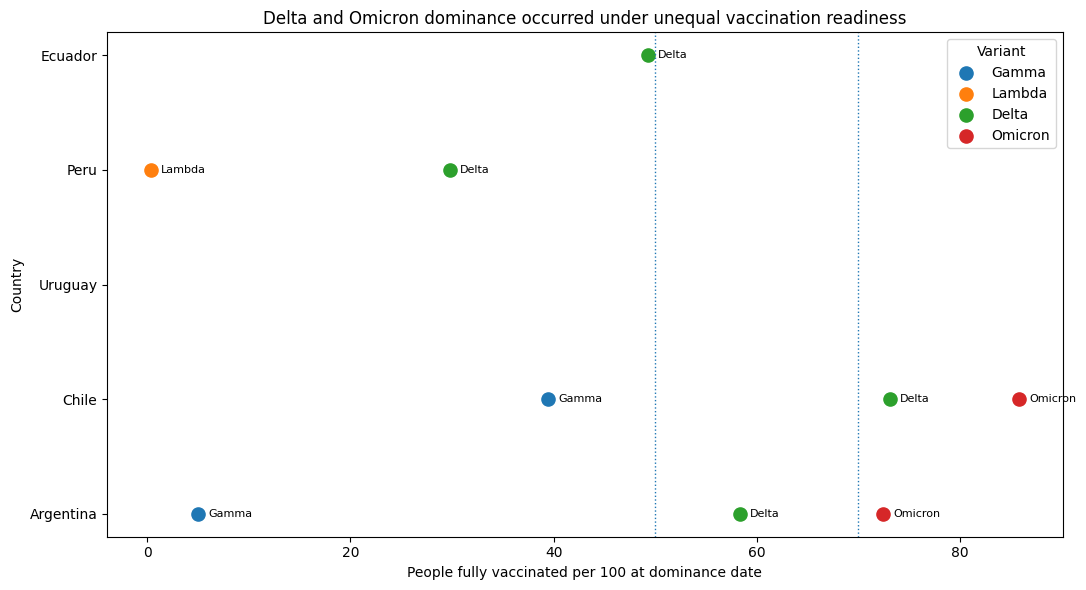

In [ ]:
if variant_dominance_vaccination.empty:
    print("No reliable named-variant dominance events found using the current threshold.")
else:
    fig, ax = plt.subplots(figsize=(11, 6))

    for variant_name in [VARIANT_DISPLAY[v] for v in MAJOR_VARIANTS]:
        sub = variant_dominance_vaccination[
            variant_dominance_vaccination["variant"] == variant_name
        ]
        if sub.empty:
            continue

        ax.scatter(
            sub["fully_vaccinated_at_event"],
            sub["country"],
            s=90,
            label=variant_name
        )

        for _, row in sub.iterrows():
            ax.text(
                row["fully_vaccinated_at_event"] + 1,
                row["country"],
                row["variant"],
                va="center",
                fontsize=8
            )

    ax.axvline(50, linestyle=":", linewidth=1)
    ax.axvline(70, linestyle=":", linewidth=1)

    ax.set_title("Delta and Omicron dominance occurred under unequal vaccination readiness")
    ax.set_xlabel("People fully vaccinated per 100 at dominance date")
    ax.set_ylabel("Country")
    ax.legend(title="Variant")

    plt.tight_layout()
    plt.show()

## 2B.7 Visual 3 — Variant Sequencing Visibility

This chart shows sequencing visibility by country. It is not a pandemic outcome chart; it is a data visibility chart.

A country with fewer sequencing dates has weaker visibility into variant timing.

The fields `first_sequencing_date` and `last_sequencing_date` describe sequencing-data coverage, not the first or last real-world appearance of a variant.

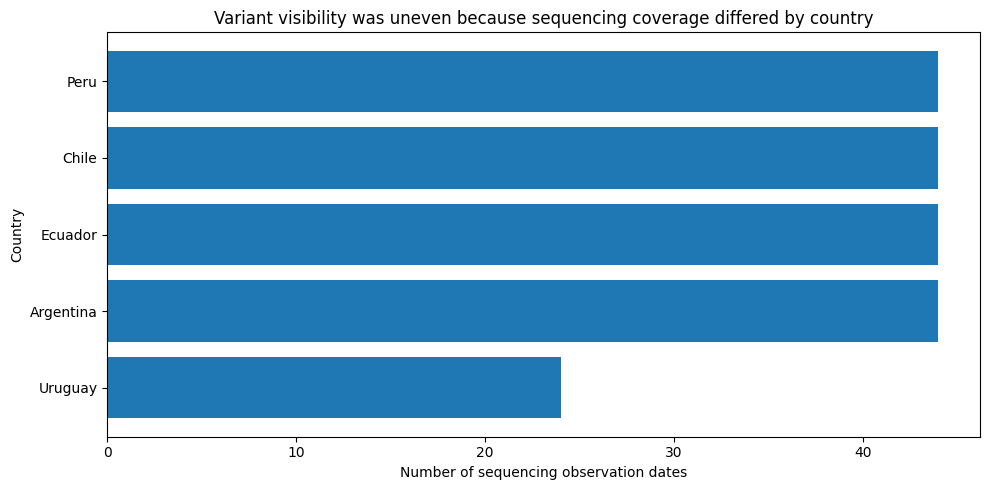

,country,variant_rows,sequencing_dates,first_sequencing_date,last_sequencing_date,median_sequences_total
0,Argentina,1056,44,2020-05-11,2021-12-27,115.0
1,Chile,1056,44,2020-05-11,2021-12-27,101.5
2,Ecuador,1056,44,2020-05-11,2021-12-27,18.5
3,Peru,1056,44,2020-05-11,2021-12-27,125.5
4,Uruguay,576,24,2020-05-11,2021-05-03,13.0


In [ ]:
variant_visibility = (
    variants_region
    .groupby("country")
    .agg(
        variant_rows=("variant", "size"),
        sequencing_dates=("date", "nunique"),
        first_sequencing_date=("date", "min"),
        last_sequencing_date=("date", "max"),
        median_sequences_total=("num_sequences_total", "median")
    )
    .reset_index()
)

variant_visibility_plot = variant_visibility.sort_values("sequencing_dates")

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    variant_visibility_plot["country"],
    variant_visibility_plot["sequencing_dates"]
)

ax.set_title("Variant visibility was uneven because sequencing coverage differed by country")
ax.set_xlabel("Number of sequencing observation dates")
ax.set_ylabel("Country")

plt.tight_layout()
plt.show()

variant_visibility

## 2B.8 Variant Timing Readiness Profile

This profile focuses on later variant pressure from Delta and Omicron.

Gamma and Lambda are still analyzed as important regional variants, but Delta and Omicron are used for the timing-readiness profile because they better test whether vaccination maturity had been reached later in the rollout.

In [ ]:
late_variants = ["Delta", "Omicron"]
late_variant_visibility_cutoff = pd.Timestamp("2021-08-01")

variant_timing_profile_rows = []

for country in COUNTRIES:
    late_events = variant_dominance_vaccination[
        (variant_dominance_vaccination["country"] == country) &
        (variant_dominance_vaccination["variant"].isin(late_variants))
    ].copy() if not variant_dominance_vaccination.empty else pd.DataFrame()

    visibility_row = variant_visibility[variant_visibility["country"] == country].iloc[0]

    if visibility_row["last_sequencing_date"] < late_variant_visibility_cutoff:
        label = "No late-variant sequencing coverage"
        earliest_late_variant_coverage = np.nan
        late_variant_events = 0
    elif late_events.empty:
        label = "No reliable Delta/Omicron dominance captured"
        earliest_late_variant_coverage = np.nan
        late_variant_events = 0
    else:
        earliest_late_variant_coverage = late_events["fully_vaccinated_at_event"].min()
        late_variant_events = len(late_events)

        if earliest_late_variant_coverage >= 70:
            label = "Later variants after vaccine maturity"
        elif earliest_late_variant_coverage >= 50:
            label = "Later variants after partial maturity"
        else:
            label = "Later variants before 50% full vaccination"

    variant_timing_profile_rows.append({
        "country": country,
        "late_variant_events_captured": late_variant_events,
        "lowest_full_vaccination_at_late_variant_dominance": earliest_late_variant_coverage,
        "sequencing_dates": visibility_row["sequencing_dates"],
        "last_sequencing_date": visibility_row["last_sequencing_date"],
        "variant_timing_readiness_label": label
    })

variant_timing_profile = pd.DataFrame(variant_timing_profile_rows)

variant_timing_profile

,country,late_variant_events_captured,lowest_full_vaccination_at_late_variant_dominance,sequencing_dates,last_sequencing_date,variant_timing_readiness_label
0,Argentina,2,58.35,44,2021-12-27,Later variants after partial maturity
1,Chile,2,73.10,44,2021-12-27,Later variants after vaccine maturity
2,Peru,1,29.77,44,2021-12-27,Later variants before 50% full vaccination
3,Ecuador,1,49.29,44,2021-12-27,Later variants before 50% full vaccination
4,Uruguay,0,NaN,24,2021-05-03,No late-variant sequencing coverage


## 2B.9 Severity Context

The comprehensive outcome dataset is cumulative, not wave-specific. Therefore, death-to-case and recovery ratios are used only as broad severity context.

We do **not** claim that one specific variant caused a specific death wave from this dataset.

In [ ]:
variant_severity_context = (
    country_summary
    .merge(variant_visibility, on="country", how="left")
    .merge(
        variant_timing_profile.drop(
            columns=["sequencing_dates", "last_sequencing_date"],
            errors="ignore"
        ),
        on="country",
        how="left"
    )
)

variant_severity_context[
    [
        "country",
        "death_to_case_ratio",
        "recovery_ratio",
        "sequencing_dates",
        "last_sequencing_date",
        "variant_timing_readiness_label"
    ]
]

,country,death_to_case_ratio,recovery_ratio,sequencing_dates,last_sequencing_date,variant_timing_readiness_label
0,Argentina,1.291575,98.708425,44,2021-12-27,Later variants after partial maturity
1,Chile,1.161076,98.838924,44,2021-12-27,Later variants after vaccine maturity
2,Peru,4.880515,95.119485,44,2021-12-27,Later variants before 50% full vaccination
3,Ecuador,3.349915,96.650085,44,2021-12-27,Later variants before 50% full vaccination
4,Uruguay,0.734661,99.265339,24,2021-05-03,No late-variant sequencing coverage


Because deaths and recoveries are available only as cumulative country-level outcomes, they are used as broad severity context rather than wave-specific impact evidence. Peru and Ecuador show the highest cumulative death-to-case ratios in the selected group, and both faced Delta before reaching 50% full vaccination in the available data. This does not prove Delta caused higher mortality, but it suggests these countries entered later variant pressure with weaker vaccination readiness and higher cumulative severity context.

### 2B Variant-Pressure Summary

Within the limits of the available data, the strongest variant-pressure events were Gamma in Argentina/Chile, Lambda in Peru, and Delta across Peru/Ecuador/Chile/Argentina. These are treated as pressure events because they reached high sequencing prevalence, not as proven causes of death changes.

## 2B Interpretation

**Finding:** Variant pressure differed across the selected countries. Gamma, Lambda, Delta, and Omicron did not follow one identical regional pattern.

**Evidence:** We used the long-format variant dataset to summarize first observation, 10% emergence, reliable 50% dominance, maximum percentage, and vaccination coverage at dominance. We also checked sequencing visibility by country.

**Implication:** Vaccination coverage must be interpreted against variant timing. A country that reached high coverage before Delta or Omicron dominance had a stronger timing-readiness profile than a country that reached coverage later. However, sparse sequencing means missing variant records are visibility gaps, not proof of absence.

**Recommendation:** Later readiness analysis should combine vaccination rollout and variant sequencing visibility instead of treating variant timelines as complete daily surveillance.

# 2C. Manufacturer Supply Resilience

## Question

Did the selected countries rely on narrow or diversified vaccine manufacturer portfolios?

This section analyzes manufacturer mix as a **supply resilience** dimension of pandemic readiness. The goal is not to determine which vaccine was biologically better. The dataset only shows administered doses by manufacturer over time, so it can support analysis of supply mix, portfolio concentration, and dependency.

Manufacturer data is cumulative by manufacturer. Therefore, final composition must use the **latest row per country and vaccine**, not the sum of all dates.

## 2C.1 Prepare Final Manufacturer Snapshot

The manufacturer dataset contains cumulative totals by `country + date + vaccine`.

For final manufacturer composition, we take the latest available row for each `country + vaccine`. We do **not** sum all dates, because that would double-count cumulative values.

In [ ]:
manufacturer_2c = manufacturer_region.sort_values(["country", "vaccine", "date"]).copy()

# Latest cumulative value for each country-manufacturer pair
manufacturer_final_mix = (
    manufacturer_2c
    .sort_values("date")
    .groupby(["country", "vaccine"], as_index=False)
    .tail(1)
    .copy()
)

# Calculate manufacturer share within each country
manufacturer_final_mix["country_total_manufacturer_doses"] = (
    manufacturer_final_mix
    .groupby("country")["total_vaccinations"]
    .transform("sum")
)

manufacturer_final_mix["manufacturer_share"] = (
    manufacturer_final_mix["total_vaccinations"] /
    manufacturer_final_mix["country_total_manufacturer_doses"]
)

manufacturer_final_mix["manufacturer_share_percent"] = (
    manufacturer_final_mix["manufacturer_share"] * 100
)

manufacturer_final_mix = manufacturer_final_mix.sort_values(
    ["country", "manufacturer_share"],
    ascending=[True, False]
).reset_index(drop=True)

manufacturer_final_mix[
    [
        "country",
        "vaccine",
        "date",
        "total_vaccinations",
        "manufacturer_share_percent"
    ]
].head(15)

,country,vaccine,date,total_vaccinations,manufacturer_share_percent
0,Argentina,Sinopharm/Beijing,2022-03-29,28322602,29.348428
1,Argentina,Oxford/AstraZeneca,2022-03-29,25977231,26.918109
2,Argentina,Sputnik V,2022-03-29,20405678,21.144758
3,Argentina,Pfizer/BioNTech,2022-03-29,14681054,15.212792
4,Argentina,Moderna,2022-03-29,6507561,6.743260
5,Argentina,CanSino,2022-03-29,610540,0.632653
6,Chile,Sinovac,2022-03-22,25596927,73.913273
7,Chile,Pfizer/BioNTech,2022-03-22,7910264,22.841551
8,Chile,CanSino,2022-03-22,574442,1.658749
9,Chile,Oxford/AstraZeneca,2022-03-22,549396,1.586427


## 2C.2 Manufacturer Portfolio Profile

We summarize each country using:

- top manufacturer,
- top manufacturer share,
- number of manufacturers used,
- Herfindahl-Hirschman Index (HHI) for portfolio concentration,
- effective number of manufacturers.

The HHI is calculated as:

```text
HHI = sum(manufacturer_share^2)
```

Higher HHI means a more concentrated manufacturer portfolio. Lower HHI means a more diversified portfolio.

This is a supply-concentration measure, not a vaccine effectiveness measure.

In [ ]:
# Top manufacturer by country
top_manufacturer = (
    manufacturer_final_mix
    .sort_values(["country", "manufacturer_share"], ascending=[True, False])
    .groupby("country")
    .first()
    .reset_index()
    [["country", "vaccine", "manufacturer_share_percent"]]
    .rename(columns={
        "vaccine": "top_manufacturer",
        "manufacturer_share_percent": "top_manufacturer_share_percent"
    })
)

# Portfolio concentration using HHI
portfolio_concentration = (
    manufacturer_final_mix
    .groupby("country")
    .agg(
        number_of_manufacturers=("vaccine", "nunique"),
        hhi=("manufacturer_share", lambda x: (x ** 2).sum()),
        final_manufacturer_total_doses=("total_vaccinations", "sum")
    )
    .reset_index()
)

portfolio_concentration["effective_number_of_manufacturers"] = (
    1 / portfolio_concentration["hhi"]
)

manufacturer_profile = (
    portfolio_concentration
    .merge(top_manufacturer, on="country", how="left")
)

def supply_resilience_label(row):
    hhi = row["hhi"]
    top_share = row["top_manufacturer_share_percent"]

    if pd.isna(hhi) or pd.isna(top_share):
        return "Insufficient data"
    if top_share >= 70 or hhi >= 0.50:
        return "Concentrated supply profile"
    elif top_share >= 50 or hhi >= 0.30:
        return "Moderately diversified supply profile"
    else:
        return "Diversified supply profile"

manufacturer_profile["manufacturer_supply_resilience_label"] = (
    manufacturer_profile.apply(supply_resilience_label, axis=1)
)

manufacturer_profile = manufacturer_profile.sort_values(
    "top_manufacturer_share_percent",
    ascending=False
).reset_index(drop=True)

manufacturer_profile

,country,number_of_manufacturers,hhi,final_manufacturer_total_doses,effective_number_of_manufacturers,top_manufacturer,top_manufacturer_share_percent,manufacturer_supply_resilience_label
0,Chile,4,0.599018,34631029,1.669400,Sinovac,73.913273,Concentrated supply profile
1,Peru,3,0.472254,65552891,2.117504,Pfizer/BioNTech,60.789070,Moderately diversified supply profile
2,Uruguay,3,0.493559,5815259,2.026098,Sinovac,55.851889,Moderately diversified supply profile
3,Ecuador,4,0.389599,29911659,2.566741,Sinovac,52.865456,Moderately diversified supply profile
4,Argentina,6,0.231032,96504666,4.328411,Sinopharm/Beijing,29.348428,Diversified supply profile


The supply-resilience label is a communication label, not a final performance grade. It summarizes whether a country depended heavily on one manufacturer or had a more distributed vaccine portfolio.

## 2C.3 Regional Manufacturer Mix

This table shows which manufacturers contributed the largest share of doses across the selected countries combined.

In [ ]:
regional_manufacturer_mix = (
    manufacturer_final_mix
    .groupby("vaccine")
    .agg(
        regional_total_doses=("total_vaccinations", "sum"),
        countries_using=("country", "nunique")
    )
    .reset_index()
)

regional_manufacturer_mix["regional_share_percent"] = (
    regional_manufacturer_mix["regional_total_doses"] /
    regional_manufacturer_mix["regional_total_doses"].sum() * 100
)

regional_manufacturer_mix = regional_manufacturer_mix.sort_values(
    "regional_share_percent",
    ascending=False
).reset_index(drop=True)

regional_manufacturer_mix

,vaccine,regional_total_doses,countries_using,regional_share_percent
0,Pfizer/BioNTech,73469585,5,31.611310
1,Sinopharm/Beijing,48626879,2,20.922390
2,Sinovac,44657794,3,19.214636
3,Oxford/AstraZeneca,37026143,5,15.931013
4,Sputnik V,20405678,1,8.779826
5,Moderna,6507561,1,2.799969
6,CanSino,1721864,3,0.740856


## 2C.4 Visual 1 — Manufacturer Share Heatmap

This heatmap shows the final manufacturer share by country. It is useful for identifying dependency patterns and portfolio diversity.

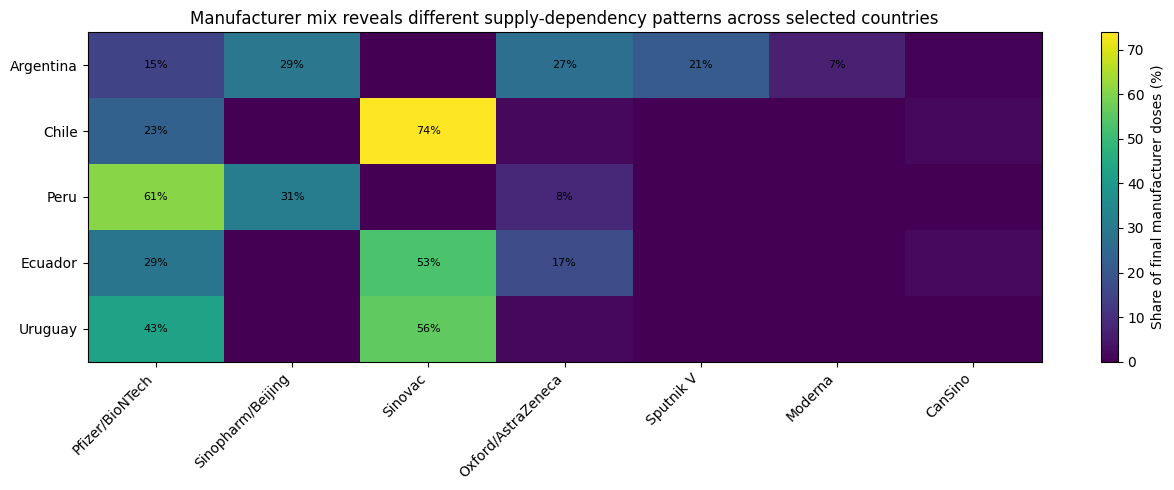

In [ ]:
# Order manufacturers by regional share so the most important manufacturers appear first
manufacturer_order = regional_manufacturer_mix["vaccine"].tolist()

manufacturer_share_pivot = (
    manufacturer_final_mix
    .pivot_table(
        index="country",
        columns="vaccine",
        values="manufacturer_share_percent",
        fill_value=0
    )
    .reindex(index=COUNTRIES)
)

# Keep available columns in regional-share order
manufacturer_share_pivot = manufacturer_share_pivot[
    [col for col in manufacturer_order if col in manufacturer_share_pivot.columns]
]

fig, ax = plt.subplots(figsize=(13, 5))

im = ax.imshow(manufacturer_share_pivot.values, aspect="auto")

ax.set_xticks(np.arange(len(manufacturer_share_pivot.columns)))
ax.set_yticks(np.arange(len(manufacturer_share_pivot.index)))

ax.set_xticklabels(manufacturer_share_pivot.columns, rotation=45, ha="right")
ax.set_yticklabels(manufacturer_share_pivot.index)

ax.set_title("Manufacturer mix reveals different supply-dependency patterns across selected countries")

# Add labels for meaningful shares
for i in range(manufacturer_share_pivot.shape[0]):
    for j in range(manufacturer_share_pivot.shape[1]):
        value = manufacturer_share_pivot.iloc[i, j]
        if value >= 5:
            ax.text(j, i, f"{value:.0f}%", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Share of final manufacturer doses (%)")

plt.tight_layout()
plt.show()

## 2C.5 Visual 2 — Final Manufacturer Composition

This stacked bar chart shows each country's final vaccine manufacturer composition.

It supports the supply-resilience interpretation by showing whether each country followed a concentrated or diversified supply path.

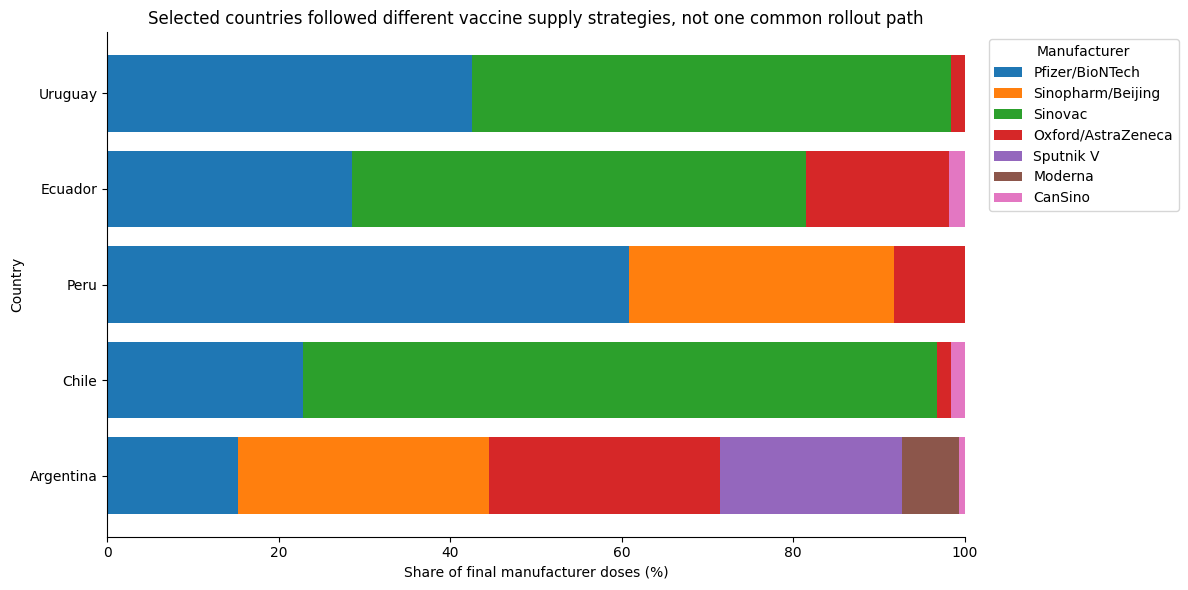

In [ ]:
composition_pivot = manufacturer_share_pivot.copy()

fig, ax = plt.subplots(figsize=(12, 6))

left = np.zeros(len(composition_pivot))

for vaccine in composition_pivot.columns:
    values = composition_pivot[vaccine].values
    ax.barh(
        composition_pivot.index,
        values,
        left=left,
        label=vaccine
    )
    left += values

ax.set_title("Selected countries followed different vaccine supply strategies, not one common rollout path")
ax.set_xlabel("Share of final manufacturer doses (%)")
ax.set_ylabel("Country")
ax.set_xlim(0, 100)

ax.legend(
    title="Manufacturer",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Remove top and right borders to maximize the data-ink ratio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 2C.6 Visual 3 — Top-Manufacturer Dependency

This chart focuses on the share of each country's top manufacturer. A higher top-manufacturer share means stronger dependency on one manufacturer.

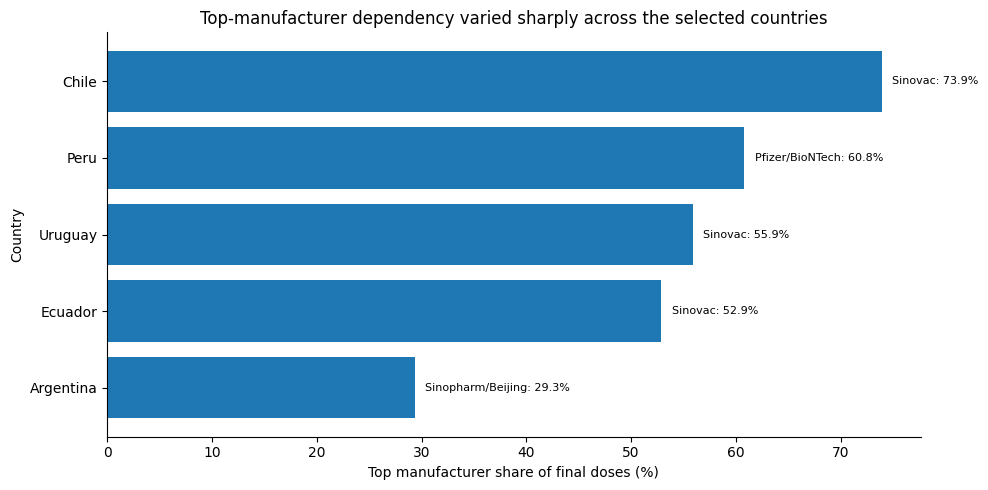

In [ ]:
dependency_plot = manufacturer_profile.sort_values("top_manufacturer_share_percent")

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    dependency_plot["country"],
    dependency_plot["top_manufacturer_share_percent"]
)

ax.set_title("Top-manufacturer dependency varied sharply across the selected countries")
ax.set_xlabel("Top manufacturer share of final doses (%)")
ax.set_ylabel("Country")

for i, row in dependency_plot.reset_index(drop=True).iterrows():
    ax.text(
        row["top_manufacturer_share_percent"] + 1,
        i,
        f'{row["top_manufacturer"]}: {row["top_manufacturer_share_percent"]:.1f}%',
        va="center",
        fontsize=8
    )

# Remove top and right borders to maximize the data-ink ratio
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 2C.7 Link Manufacturer Profile to Vaccination Rollout

This table connects manufacturer supply resilience to the vaccination rollout profile from 2A.

The goal is not to prove causality. It is to see whether countries with different supply portfolios also showed different rollout profiles.

In [ ]:
manufacturer_vaccination_profile = (
    manufacturer_profile
    .merge(vaccination_interpretation, on="country", how="left")
    .sort_values("country")
    .reset_index(drop=True)
)

manufacturer_vaccination_profile[
    [
        "country",
        "top_manufacturer",
        "top_manufacturer_share_percent",
        "number_of_manufacturers",
        "hhi",
        "effective_number_of_manufacturers",
        "manufacturer_supply_resilience_label",
        "vaccination_readiness_label",
        "final_fully_vaccinated_per_100",
        "days_to_70_full"
    ]
]

,country,top_manufacturer,top_manufacturer_share_percent,number_of_manufacturers,hhi,effective_number_of_manufacturers,manufacturer_supply_resilience_label,vaccination_readiness_label,final_fully_vaccinated_per_100,days_to_70_full
0,Argentina,Sinopharm/Beijing,29.348428,6,0.231032,4.328411,Diversified supply profile,Later rollout profile within selected countries,80.96,350
1,Chile,Sinovac,73.913273,4,0.599018,1.669400,Concentrated supply profile,Earlier/deeper rollout profile,90.29,245
2,Ecuador,Sinovac,52.865456,4,0.389599,2.566741,Moderately diversified supply profile,Later rollout profile within selected countries,76.64,338
3,Peru,Pfizer/BioNTech,60.789070,3,0.472254,2.117504,Moderately diversified supply profile,Later rollout profile within selected countries,76.38,372
4,Uruguay,Sinovac,55.851889,3,0.493559,2.026098,Moderately diversified supply profile,Earlier/deeper rollout profile,81.56,172


## 2C.8 Manufacturer Interpretation Table

This table is the dimension-level manufacturer profile that will later feed into the final readiness profile.

In [ ]:
manufacturer_interpretation = manufacturer_profile[
    [
        "country",
        "top_manufacturer",
        "top_manufacturer_share_percent",
        "number_of_manufacturers",
        "hhi",
        "effective_number_of_manufacturers",
        "manufacturer_supply_resilience_label"
    ]
].copy()

manufacturer_interpretation

,country,top_manufacturer,top_manufacturer_share_percent,number_of_manufacturers,hhi,effective_number_of_manufacturers,manufacturer_supply_resilience_label
0,Chile,Sinovac,73.913273,4,0.599018,1.669400,Concentrated supply profile
1,Peru,Pfizer/BioNTech,60.789070,3,0.472254,2.117504,Moderately diversified supply profile
2,Uruguay,Sinovac,55.851889,3,0.493559,2.026098,Moderately diversified supply profile
3,Ecuador,Sinovac,52.865456,4,0.389599,2.566741,Moderately diversified supply profile
4,Argentina,Sinopharm/Beijing,29.348428,6,0.231032,4.328411,Diversified supply profile


### 2C Interpretation Limits

The manufacturer analysis describes vaccine supply mix and portfolio concentration, not biological vaccine effectiveness. A concentrated supply profile means higher dependency on one manufacturer, not failure. A diversified profile means the country used a wider portfolio, not necessarily that its rollout was automatically better.

The regional manufacturer mix is dose-weighted because it is calculated from cumulative manufacturer doses. Larger countries or countries with more total doses have more influence on the regional mix.

### 2C Potential Reasons and Interpretation Limits

Possible reasons for manufacturer dominance include earlier availability, procurement agreements, delivery reliability, storage and logistics constraints, and national rollout strategy. These are treated as plausible explanations, not proven causes, because the dataset does not include procurement contracts, delivery schedules, pricing, public acceptance, or policy decisions.

## 2C Interpretation

**Finding:** The selected countries did not follow one common vaccine supply path. Some countries relied heavily on one dominant manufacturer, while others used more diversified manufacturer portfolios.

**Evidence:** We compared final manufacturer shares, top-manufacturer dependency, number of manufacturers used, and HHI portfolio concentration. The heatmap and stacked composition chart show clear differences in vaccine supply mix across countries.

**Implication:** High vaccination coverage alone does not reveal supply dependency. A country may achieve strong rollout coverage while still relying heavily on a narrow manufacturer portfolio. This matters because concentrated supply portfolios can create vulnerability if supply chains, procurement agreements, or vaccine availability change.

**Recommendation:** Future pandemic dashboards should monitor vaccine portfolio concentration alongside rollout coverage. Manufacturer data should be interpreted as supply strategy and deployment contribution, not biological vaccine effectiveness.

# 2D. Testing Visibility

## Question

How visible and comparable was the pandemic in official testing data?

Testing is treated as the fourth readiness dimension. It is not only a public-health activity; it is also a measurement system. If testing is weak or inconsistent, reported case counts become harder to compare because infections may be under-detected.

This section avoids forcing a weak scatterplot relationship because the dataset has only five countries, testing is time-series data, outcomes are static cumulative data, and testing definitions differ across countries. Instead, we use direct visibility indicators: testing intensity, positivity, tests per case, missingness, and testing method.

## 2D.1 Prepare Testing Data

We work from `testing_region`, which was created in Part 1.

Testing columns are kept in their original meaning. We do not fill positivity or tests-per-case values because missingness may reflect reporting gaps.

In [ ]:
testing_2d = testing_region.sort_values(["country", "date"]).copy()

testing_key_columns = [
    "Cumulative total per thousand",
    "7-day smoothed daily change per thousand",
    "Short-term positive rate",
    "Short-term tests per case"
]

existing_testing_key_columns = [
    col for col in testing_key_columns if col in testing_2d.columns
]

testing_2d[["country", "date", "testing_method"] + existing_testing_key_columns].head()

,country,date,testing_method,Cumulative total per thousand,7-day smoothed daily change per thousand,Short-term positive rate,Short-term tests per case
828,Argentina,2020-01-01,tests performed,0.000,NaN,NaN,NaN
829,Argentina,2020-01-02,tests performed,0.001,NaN,NaN,NaN
830,Argentina,2020-01-03,tests performed,0.001,NaN,NaN,NaN
831,Argentina,2020-01-04,tests performed,0.003,NaN,NaN,NaN
832,Argentina,2020-01-05,tests performed,0.003,NaN,NaN,NaN


## 2D.2 Testing Method Reminder

Testing definitions differ across countries, so testing metrics are interpreted as visibility indicators rather than perfectly equivalent testing volume.

In [ ]:
testing_method_summary = (
    testing_2d
    .groupby("country")["testing_method"]
    .unique()
    .reset_index()
)

testing_method_summary

,country,testing_method
0,Argentina,[tests performed]
1,Chile,[tests performed]
2,Ecuador,[people tested]
3,Peru,[tests performed]
4,Uruguay,[people tested]


## 2D.3 Testing Visibility Summary

This summary compares countries using:

- final cumulative tests per thousand,
- median positive rate,
- median tests per case,
- number of testing observation dates,
- missingness in key testing indicators,
- testing method.

A high positivity rate or low tests-per-case value can indicate weaker detection visibility, because testing may be capturing only a smaller or more symptomatic part of infections.

In [ ]:
def last_non_null(series):
    non_null = series.dropna()
    if non_null.empty:
        return np.nan
    return non_null.iloc[-1]


testing_summary_rows = []

for country in COUNTRIES:
    sub = testing_2d[testing_2d["country"] == country].sort_values("date").copy()

    row = {
        "country": country,
        "testing_rows": len(sub),
        "testing_observation_dates": sub["date"].nunique(),
        "first_testing_date": sub["date"].min(),
        "last_testing_date": sub["date"].max(),
        "testing_method": ", ".join(sorted(sub["testing_method"].dropna().unique()))
    }

    if "Cumulative total per thousand" in sub.columns:
        row["final_cumulative_tests_per_thousand"] = last_non_null(sub["Cumulative total per thousand"])
        row["cumulative_tests_missing_pct"] = sub["Cumulative total per thousand"].isna().mean() * 100

    if "7-day smoothed daily change per thousand" in sub.columns:
        row["median_smoothed_daily_tests_per_thousand"] = sub["7-day smoothed daily change per thousand"].median(skipna=True)
        row["smoothed_daily_tests_missing_pct"] = sub["7-day smoothed daily change per thousand"].isna().mean() * 100

    if "Short-term positive rate" in sub.columns:
        row["median_positive_rate"] = sub["Short-term positive rate"].median(skipna=True)
        row["positive_rate_missing_pct"] = sub["Short-term positive rate"].isna().mean() * 100

    if "Short-term tests per case" in sub.columns:
        row["median_tests_per_case"] = sub["Short-term tests per case"].median(skipna=True)
        row["tests_per_case_missing_pct"] = sub["Short-term tests per case"].isna().mean() * 100

    testing_summary_rows.append(row)

testing_visibility_summary = pd.DataFrame(testing_summary_rows)

# Convert positive rate to percent for readability if it is stored as a proportion.
if "median_positive_rate" in testing_visibility_summary.columns:
    testing_visibility_summary["median_positive_rate_percent"] = (
        testing_visibility_summary["median_positive_rate"] * 100
    )

testing_visibility_summary

,country,testing_rows,testing_observation_dates,first_testing_date,last_testing_date,testing_method,final_cumulative_tests_per_thousand,cumulative_tests_missing_pct,median_smoothed_daily_tests_per_thousand,smoothed_daily_tests_missing_pct,median_positive_rate,positive_rate_missing_pct,median_tests_per_case,tests_per_case_missing_pct,median_positive_rate_percent
0,Argentina,704,704,2020-01-01,2021-12-04,tests performed,579.560,2.414773,0.715,0.994318,0.18500,3.267045,5.4,3.267045,18.500
1,Chile,625,625,2020-03-25,2021-12-09,tests performed,1349.738,0.000000,2.494,1.120000,0.07045,1.120000,14.2,1.120000,7.045
2,Peru,673,673,2020-01-01,2021-11-03,tests performed,178.690,3.268945,0.281,1.040119,0.10800,4.160475,9.1,5.200594,10.800
3,Ecuador,630,630,2020-03-18,2021-12-07,people tested,108.481,4.126984,0.174,1.111111,0.25685,28.571429,3.9,28.730159,25.685
4,Uruguay,628,628,2020-03-22,2021-12-09,people tested,1199.691,0.000000,1.945,1.114650,0.02070,1.114650,48.3,1.114650,2.070


## 2D.4 Testing Visibility Profile

We create a lightweight testing visibility profile using relative indicators within the selected countries.

The profile is not a final country performance ranking. It summarizes how visible the pandemic appears in the available testing data.

Higher visibility is associated with:

- more cumulative tests per thousand,
- lower positive rate,
- more tests per case,
- lower missingness in key testing indicators.

Because testing definitions differ, the profile is interpreted cautiously.

In [ ]:
testing_profile = testing_visibility_summary.copy()

# Missingness average across available key fields
missingness_cols = [
    col for col in [
        "cumulative_tests_missing_pct",
        "smoothed_daily_tests_missing_pct",
        "positive_rate_missing_pct",
        "tests_per_case_missing_pct"
    ]
    if col in testing_profile.columns
]

testing_profile["average_testing_missing_pct"] = (
    testing_profile[missingness_cols].mean(axis=1)
    if missingness_cols else np.nan
)

# Use normalization helpers from 2A if they exist. If not, define them here.
if "normalize_high_good" not in globals():
    def normalize_high_good(series):
        min_val = series.min(skipna=True)
        max_val = series.max(skipna=True)
        if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
            return pd.Series(1, index=series.index)
        return (series - min_val) / (max_val - min_val)

if "normalize_low_good" not in globals():
    def normalize_low_good(series):
        min_val = series.min(skipna=True)
        max_val = series.max(skipna=True)
        if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
            return pd.Series(1, index=series.index)
        return (max_val - series) / (max_val - min_val)

testing_profile["testing_intensity_score"] = normalize_high_good(
    testing_profile["final_cumulative_tests_per_thousand"]
)

testing_profile["positive_rate_score"] = normalize_low_good(
    testing_profile["median_positive_rate_percent"]
)

testing_profile["tests_per_case_score"] = normalize_high_good(
    testing_profile["median_tests_per_case"]
)

testing_profile["completeness_score"] = normalize_low_good(
    testing_profile["average_testing_missing_pct"]
)

testing_profile["testing_visibility_index"] = (
    0.35 * testing_profile["testing_intensity_score"] +
    0.25 * testing_profile["positive_rate_score"] +
    0.25 * testing_profile["tests_per_case_score"] +
    0.15 * testing_profile["completeness_score"]
)

def testing_visibility_label(score):
    if pd.isna(score):
        return "Insufficient data"
    if score >= 0.70:
        return "Higher testing visibility profile"
    elif score >= 0.40:
        return "Middle testing visibility profile"
    else:
        return "Lower testing visibility profile within selected countries"

testing_profile["testing_visibility_label"] = (
    testing_profile["testing_visibility_index"].apply(testing_visibility_label)
)

testing_profile = testing_profile.sort_values(
    "testing_visibility_index",
    ascending=False
).reset_index(drop=True)

testing_profile[
    [
        "country",
        "testing_method",
        "final_cumulative_tests_per_thousand",
        "median_positive_rate_percent",
        "median_tests_per_case",
        "average_testing_missing_pct",
        "testing_visibility_index",
        "testing_visibility_label"
    ]
]

,country,testing_method,final_cumulative_tests_per_thousand,median_positive_rate_percent,median_tests_per_case,average_testing_missing_pct,testing_visibility_index,testing_visibility_label
0,Uruguay,people tested,1199.691,2.070,48.3,0.835987,0.957691,Higher testing visibility profile
1,Chile,tests performed,1349.738,7.045,14.2,0.840000,0.755287,Higher testing visibility profile
2,Argentina,tests performed,579.560,18.500,5.4,2.485795,0.350619,Lower testing visibility profile within select...
3,Peru,tests performed,178.690,10.800,9.1,3.417533,0.330490,Lower testing visibility profile within select...
4,Ecuador,people tested,108.481,25.685,3.9,15.634921,0.000000,Lower testing visibility profile within select...


## 2D.5 Visual 1 — Testing Intensity Over Time

This line chart shows cumulative testing intensity over time.

It is safer than a correlation scatterplot because it directly shows how testing visibility changed through the pandemic period.

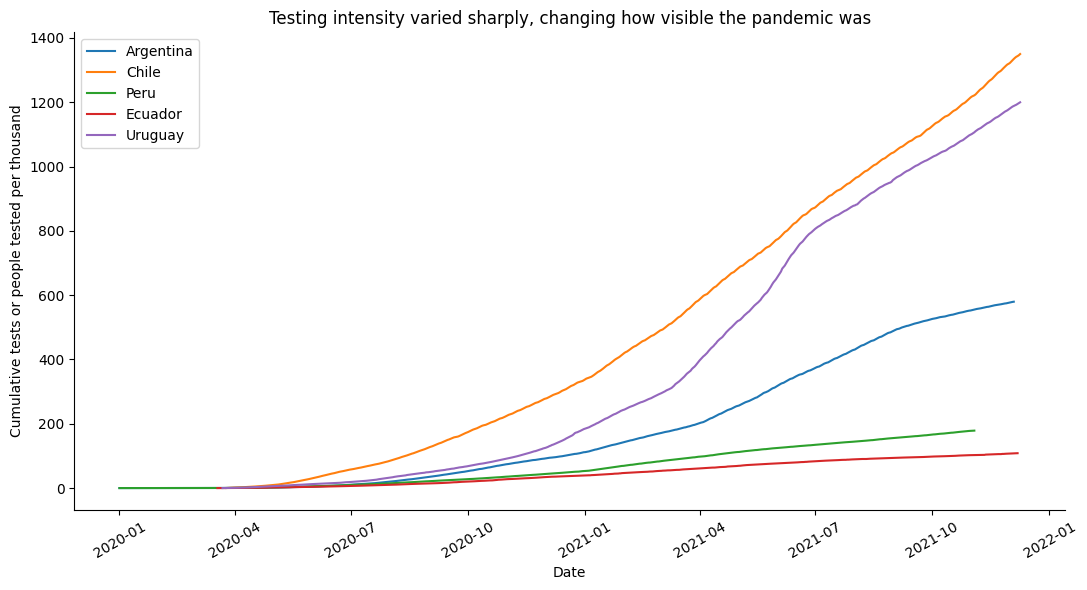

In [ ]:
testing_trend = testing_2d.sort_values(["country", "date"]).copy()

# Cumulative testing values may be forward-filled for trend visualization only.
# This does not change missingness reporting.
if "Cumulative total per thousand" in testing_trend.columns:
    testing_trend["Cumulative total per thousand (ffill)"] = (
        testing_trend
        .groupby("country")["Cumulative total per thousand"]
        .ffill()
    )

fig, ax = plt.subplots(figsize=(11, 6))

for country in COUNTRIES:
    sub = testing_trend[testing_trend["country"] == country]
    ax.plot(
        sub["date"],
        sub["Cumulative total per thousand (ffill)"],
        label=country
    )

ax.set_title("Testing intensity varied sharply, changing how visible the pandemic was")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative tests or people tested per thousand")
ax.legend()
plt.xticks(rotation=30)

# Remove top and right borders to maximize the data-ink ratio
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 2D.6 Visual 2 — Testing Visibility Summary

This chart compares final cumulative testing intensity by country. Labels include the testing method because `tests performed` and `people tested` are not identical definitions.

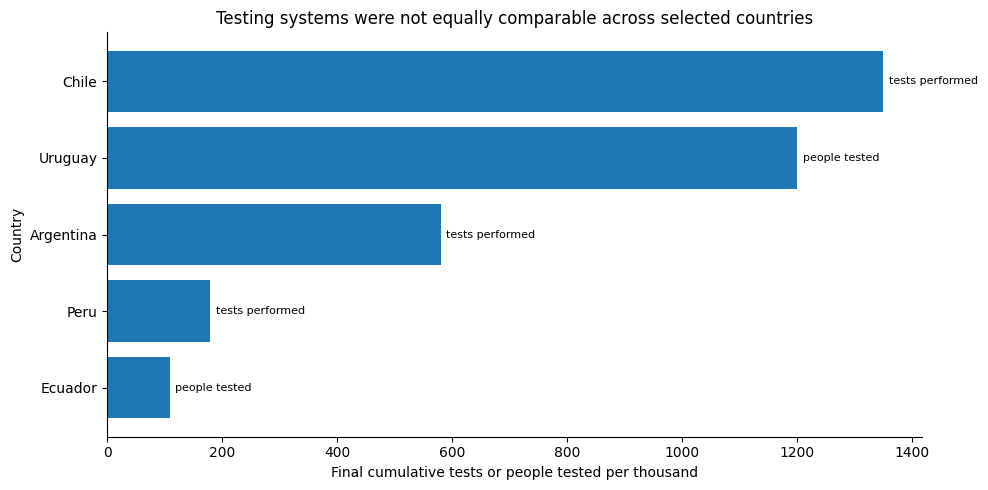

In [ ]:
testing_bar = testing_profile.sort_values("final_cumulative_tests_per_thousand")

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    testing_bar["country"],
    testing_bar["final_cumulative_tests_per_thousand"]
)

ax.set_title("Testing systems were not equally comparable across selected countries")
ax.set_xlabel("Final cumulative tests or people tested per thousand")
ax.set_ylabel("Country")

for i, row in testing_bar.reset_index(drop=True).iterrows():
    label = f'{row["testing_method"]}'
    ax.text(
        row["final_cumulative_tests_per_thousand"] + 10,
        i,
        label,
        va="center",
        fontsize=8
    )

# Remove top and right borders to maximize the data-ink ratio
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## 2D.7 Visual 3 — Testing Missingness Heatmap

This heatmap shows missingness in key testing indicators by country.

It supports the data-management point that testing quality and completeness affect how confidently reported cases can be interpreted.

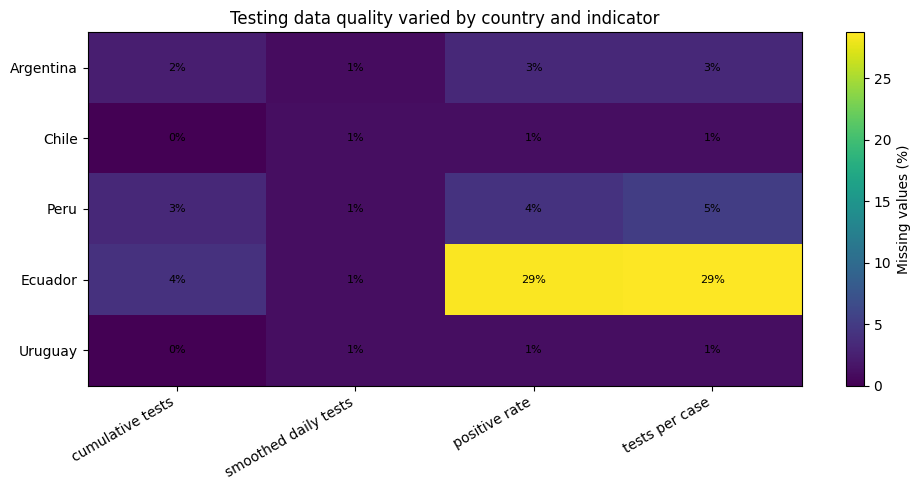

In [ ]:
missingness_heatmap_cols = [
    col for col in [
        "cumulative_tests_missing_pct",
        "smoothed_daily_tests_missing_pct",
        "positive_rate_missing_pct",
        "tests_per_case_missing_pct"
    ]
    if col in testing_visibility_summary.columns
]

testing_missingness_matrix = (
    testing_visibility_summary
    .set_index("country")[missingness_heatmap_cols]
    .reindex(COUNTRIES)
)

# Shorter labels for chart readability
short_missingness_labels = {
    "cumulative_tests_missing_pct": "cumulative tests",
    "smoothed_daily_tests_missing_pct": "smoothed daily tests",
    "positive_rate_missing_pct": "positive rate",
    "tests_per_case_missing_pct": "tests per case"
}

fig, ax = plt.subplots(figsize=(10, 5))

im = ax.imshow(testing_missingness_matrix.values, aspect="auto")

ax.set_xticks(np.arange(len(testing_missingness_matrix.columns)))
ax.set_yticks(np.arange(len(testing_missingness_matrix.index)))

ax.set_xticklabels(
    [short_missingness_labels.get(col, col) for col in testing_missingness_matrix.columns],
    rotation=30,
    ha="right"
)

ax.set_yticklabels(testing_missingness_matrix.index)

ax.set_title("Testing data quality varied by country and indicator")

for i in range(testing_missingness_matrix.shape[0]):
    for j in range(testing_missingness_matrix.shape[1]):
        value = testing_missingness_matrix.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.0f}%", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="Missing values (%)")

plt.tight_layout()
plt.show()

## 2D.8 Testing Intensity and Reported Outcomes Relationship

The assignment asks us to explore the relationship between testing intensity and reported case counts.

We avoid a scatterplot because only five countries are included, outcomes are static cumulative values, and testing definitions differ. Instead, this table compares testing visibility indicators with cumulative outcome context.

This is interpreted as a visibility relationship, not causal proof.

Raw cumulative case counts are shown only as broad outcome context because they are not population-normalized and are affected by testing visibility. Therefore, the relationship is interpreted through detection indicators such as positivity rate and tests per case rather than through raw case totals alone.

In [ ]:
testing_outcome_context = (
    testing_profile
    .merge(country_summary, on="country", how="left")
)

testing_outcome_context[
    [
        "country",
        "testing_method",
        "final_cumulative_tests_per_thousand",
        "median_positive_rate_percent",
        "median_tests_per_case",
        "Cases",
        "death_to_case_ratio",
        "testing_visibility_label"
    ]
]

,country,testing_method,final_cumulative_tests_per_thousand,median_positive_rate_percent,median_tests_per_case,Cases,death_to_case_ratio,testing_visibility_label
0,Uruguay,people tested,1199.691,2.070,48.3,1037893.0,0.734661,Higher testing visibility profile
1,Chile,tests performed,1349.738,7.045,14.2,5399992.0,1.161076,Higher testing visibility profile
2,Argentina,tests performed,579.560,18.500,5.4,10131586.0,1.291575,Lower testing visibility profile within select...
3,Peru,tests performed,178.690,10.800,9.1,4524748.0,4.880515,Lower testing visibility profile within select...
4,Ecuador,people tested,108.481,25.685,3.9,1076087.0,3.349915,Lower testing visibility profile within select...


Countries with weaker testing visibility may have less comparable reported case counts, because low testing intensity, high positivity, or low tests per case can indicate that infections were under-detected. This does not prove that testing caused higher deaths or cases. It means reported cases are only as reliable as the testing system behind them.

## 2D.9 Testing Interpretation Table

This table is the dimension-level testing profile that will later feed into the final readiness profile.

In [ ]:
testing_interpretation = testing_profile[
    [
        "country",
        "testing_method",
        "final_cumulative_tests_per_thousand",
        "median_positive_rate_percent",
        "median_tests_per_case",
        "average_testing_missing_pct",
        "testing_visibility_label"
    ]
].copy()

testing_interpretation

,country,testing_method,final_cumulative_tests_per_thousand,median_positive_rate_percent,median_tests_per_case,average_testing_missing_pct,testing_visibility_label
0,Uruguay,people tested,1199.691,2.070,48.3,0.835987,Higher testing visibility profile
1,Chile,tests performed,1349.738,7.045,14.2,0.840000,Higher testing visibility profile
2,Argentina,tests performed,579.560,18.500,5.4,2.485795,Lower testing visibility profile within select...
3,Peru,tests performed,178.690,10.800,9.1,3.417533,Lower testing visibility profile within select...
4,Ecuador,people tested,108.481,25.685,3.9,15.634921,Lower testing visibility profile within select...


## 2D Interpretation

**Finding:** Testing visibility differed across the selected countries. Testing intensity, missingness, positivity, tests per case, and testing definitions all affect how comparable reported case counts are.

**Evidence:** We compared cumulative testing per thousand, median positivity, median tests per case, testing-method definitions, and missingness in key testing indicators. We also connected these testing indicators to cumulative cases and death-to-case ratios as broad outcome context.

**Implication:** Reported cases are not purely a disease metric; they are also a measurement-system output. Countries with lower testing visibility may have hidden infections that are not fully reflected in official case counts.

**Recommendation:** Future pandemic dashboards should monitor testing visibility alongside cases, deaths, variants, and vaccination coverage. Without testing visibility, public-health data risks becoming dark pandemic data.

# Part 2 Integrated Readiness Profile

## Question

What does the combined evidence say about pandemic readiness across the selected South American countries?

This final profile table connects the four Part 2 dimensions:

- vaccination readiness,
- variant timing readiness,
- manufacturer supply resilience,
- testing visibility.

The goal is not to produce a single winner ranking. The goal is to summarize each country's readiness profile using evidence from all four analyses.

In [ ]:
# Build dimension-level tables for the final readiness profile

vaccination_profile_final = vaccination_interpretation[
    ["country", "vaccination_readiness_label"]
].copy()

variant_profile_final = variant_timing_profile[
    ["country", "variant_timing_readiness_label"]
].copy()

manufacturer_profile_final = manufacturer_interpretation[
    [
        "country",
        "manufacturer_supply_resilience_label",
        "top_manufacturer",
        "top_manufacturer_share_percent"
    ]
].copy()

testing_profile_final = testing_interpretation[
    ["country", "testing_visibility_label"]
].copy()

readiness_profile = (
    pd.DataFrame({"country": COUNTRIES})
    .merge(vaccination_profile_final, on="country", how="left")
    .merge(variant_profile_final, on="country", how="left")
    .merge(manufacturer_profile_final, on="country", how="left")
    .merge(testing_profile_final, on="country", how="left")
)

def profile_summary(row):
    country = row["country"]
    vacc = row["vaccination_readiness_label"]
    variant = row["variant_timing_readiness_label"]
    manuf = row["manufacturer_supply_resilience_label"]
    top_manuf = row["top_manufacturer"]
    top_share = row["top_manufacturer_share_percent"]
    testing = row["testing_visibility_label"]

    manufacturer_phrase = (
        f"{manuf}; top manufacturer is {top_manuf} ({top_share:.1f}%)"
        if pd.notna(top_share)
        else str(manuf)
    )

    return (
        f"{country}: vaccination profile = {vacc}; "
        f"variant timing = {variant}; "
        f"manufacturer profile = {manufacturer_phrase}; "
        f"testing visibility = {testing}."
    )

readiness_profile["overall_profile"] = readiness_profile.apply(profile_summary, axis=1)

assert len(readiness_profile) == len(COUNTRIES), "Readiness profile does not contain all selected countries."

required_profile_columns = [
    "vaccination_readiness_label",
    "variant_timing_readiness_label",
    "manufacturer_supply_resilience_label",
    "testing_visibility_label"
]

assert readiness_profile[required_profile_columns].notna().all().all(), (
    "Readiness profile contains missing dimension labels."
)

print("Integrated readiness profile validation passed.")

readiness_profile

Integrated readiness profile validation passed.


,country,vaccination_readiness_label,variant_timing_readiness_label,manufacturer_supply_resilience_label,top_manufacturer,top_manufacturer_share_percent,testing_visibility_label,overall_profile
0,Argentina,Later rollout profile within selected countries,Later variants after partial maturity,Diversified supply profile,Sinopharm/Beijing,29.348428,Lower testing visibility profile within select...,Argentina: vaccination profile = Later rollout...
1,Chile,Earlier/deeper rollout profile,Later variants after vaccine maturity,Concentrated supply profile,Sinovac,73.913273,Higher testing visibility profile,Chile: vaccination profile = Earlier/deeper ro...
2,Peru,Later rollout profile within selected countries,Later variants before 50% full vaccination,Moderately diversified supply profile,Pfizer/BioNTech,60.789070,Lower testing visibility profile within select...,Peru: vaccination profile = Later rollout prof...
3,Ecuador,Later rollout profile within selected countries,Later variants before 50% full vaccination,Moderately diversified supply profile,Sinovac,52.865456,Lower testing visibility profile within select...,Ecuador: vaccination profile = Later rollout p...
4,Uruguay,Earlier/deeper rollout profile,No late-variant sequencing coverage,Moderately diversified supply profile,Sinovac,55.851889,Higher testing visibility profile,Uruguay: vaccination profile = Earlier/deeper ...


## Final Readiness Profile Interpretation

**Finding:** The selected countries show different readiness strengths and weaknesses rather than one simple winner.

**Evidence:** Vaccination analysis showed that Chile finished with the deepest coverage while Uruguay reached thresholds fastest. Variant analysis showed that Chile and Argentina faced later variants after stronger vaccination maturity, while Peru and Ecuador faced Delta before reaching 50% full vaccination in the available data. Manufacturer analysis showed that some countries had concentrated supply profiles while others used more diversified portfolios. Testing analysis showed that official case comparability depends on testing visibility and testing definitions.

**Implication:** A country can look strong on one dimension and weaker on another. For example, high vaccination coverage does not automatically mean low supply dependency, and reported cases cannot be interpreted confidently without testing visibility.

**Recommendation:** Future pandemic dashboards should integrate vaccination rollout, variant sequencing, manufacturer portfolio concentration, and testing visibility into one decision-ready view. Tracking these dimensions separately risks hiding important readiness weaknesses.